In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning methods
from sklearn.model_selection import train_test_split # data splitting into train and test
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score


In [2]:
dataSepsis = pd.read_csv("Dataset.csv", sep=",")


In [3]:
dataSepsis.head(15).T


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
S.No.,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00
Hour,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00
HR,NaN,65.00,78.00,73.00,70.00,62.00,61.00,68.00,71.00,69.00,75.00,84.00,85.00,85.00,89.00
O2Sat,NaN,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
Temp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.78,NaN,NaN,NaN,36.39,NaN,NaN,NaN
SBP,NaN,NaN,NaN,NaN,129.00,124.00,101.00,142.00,121.00,120.00,146.00,128.00,124.00,141.00,117.00
MAP,NaN,72.00,42.50,NaN,74.00,85.00,75.00,93.50,74.00,79.00,93.00,80.00,79.00,95.00,86.00
DBP,NaN,NaN,NaN,NaN,69.00,61.00,58.00,78.00,91.00,98.00,67.00,60.00,59.00,69.00,68.00
Resp,NaN,16.50,NaN,17.00,14.00,14.00,14.00,16.00,14.00,14.00,14.00,14.00,14.00,14.00,14.00
EtCO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataSepsis.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   S.No.             1048575 non-null  int64  
 1   Hour              1048575 non-null  int64  
 2   HR                956353 non-null   float64
 3   O2Sat             916891 non-null   float64
 4   Temp              354442 non-null   float64
 5   SBP               892370 non-null   float64
 6   MAP               929498 non-null   float64
 7   DBP               632209 non-null   float64
 8   Resp              916890 non-null   float64
 9   EtCO2             18587 non-null    float64
 10  BaseExcess        82955 non-null    float64
 11  HCO3              64040 non-null    float64
 12  FiO2              118069 non-null   float64
 13  pH                96427 non-null    float64
 14  PaCO2             75091 non-null    float64
 15  SaO2              44080 non-null    float64
 16  

In [5]:
dataSepsis.isna().sum(axis = 0).sort_values(ascending=False) / len(dataSepsis) * 100


Bilirubin_direct    99.830913
TroponinI           99.468231
Fibrinogen          99.279975
Bilirubin_total     98.641585
Alkalinephos        98.467444
AST                 98.441885
EtCO2               98.227404
Lactate             96.940705
PTT                 96.105667
SaO2                95.796200
Phosphate           95.472236
Calcium             94.562048
HCO3                93.892664
Platelets           93.770593
Creatinine          93.636602
Chloride            93.583006
WBC                 93.042176
Magnesium           92.953103
PaCO2               92.838757
BUN                 92.494862
BaseExcess          92.088787
Hgb                 91.901295
pH                  90.803996
Potassium           89.904299
Hct                 89.693632
FiO2                88.740052
Glucose             85.352121
Temp                66.197745
Unit2               44.005722
Unit1               44.005722
DBP                 39.707794
SBP                 14.896884
Resp                12.558472
O2Sat     

In [6]:
dataSepsis.nunique()


S.No.                 336
Hour                  336
HR                    339
O2Sat                 144
Temp                  622
SBP                   876
MAP                   930
DBP                   532
Resp                  221
EtCO2                 127
BaseExcess            285
HCO3                  216
FiO2                   96
pH                    101
PaCO2                 427
SaO2                  337
AST                  1702
BUN                   234
Alkalinephos          657
Calcium               429
Chloride              104
Creatinine           1076
Bilirubin_direct      208
Glucose              1018
Lactate              1051
Magnesium             101
Phosphate             174
Potassium             341
Bilirubin_total       373
TroponinI            1303
Hct                   681
Hgb                   312
PTT                  1322
WBC                   769
Fibrinogen            789
Platelets             931
Age                  5986
Gender                  2
Unit1       

In [7]:
dataSepsis.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
S.No.,1048575.0,25.408382,28.238308,0.00,9.00,19.00,33.00,335.00
Hour,1048575.0,25.408382,28.238308,0.00,9.00,19.00,33.00,335.00
HR,956353.0,84.870313,17.172201,20.00,73.00,84.00,96.00,280.00
O2Sat,916891.0,97.228627,2.926971,20.00,96.00,98.00,99.50,100.00
Temp,354442.0,37.003726,0.776637,20.90,36.50,37.00,37.50,50.00
SBP,892370.0,122.392746,22.490689,20.00,106.00,120.00,136.50,300.00
MAP,929498.0,80.578177,15.804974,20.00,69.67,79.00,90.00,300.00
DBP,632209.0,62.218458,13.517029,20.00,53.00,60.50,70.00,300.00
Resp,916890.0,18.754969,5.260591,1.00,15.00,18.00,22.00,100.00
EtCO2,18587.0,33.385834,8.238420,10.00,29.00,33.00,38.00,100.00


In [8]:
print(dataSepsis.columns.tolist())


['S.No.', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [9]:
dataSepsis["SepsisLabel"].value_counts()


SepsisLabel
0    1027767
1      20808
Name: count, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(dataSepsis.drop("SepsisLabel", axis=1), dataSepsis["SepsisLabel"], test_size=0.1, random_state=42)


In [11]:
sns.set_theme(context="notebook", style="whitegrid", palette="tab10")

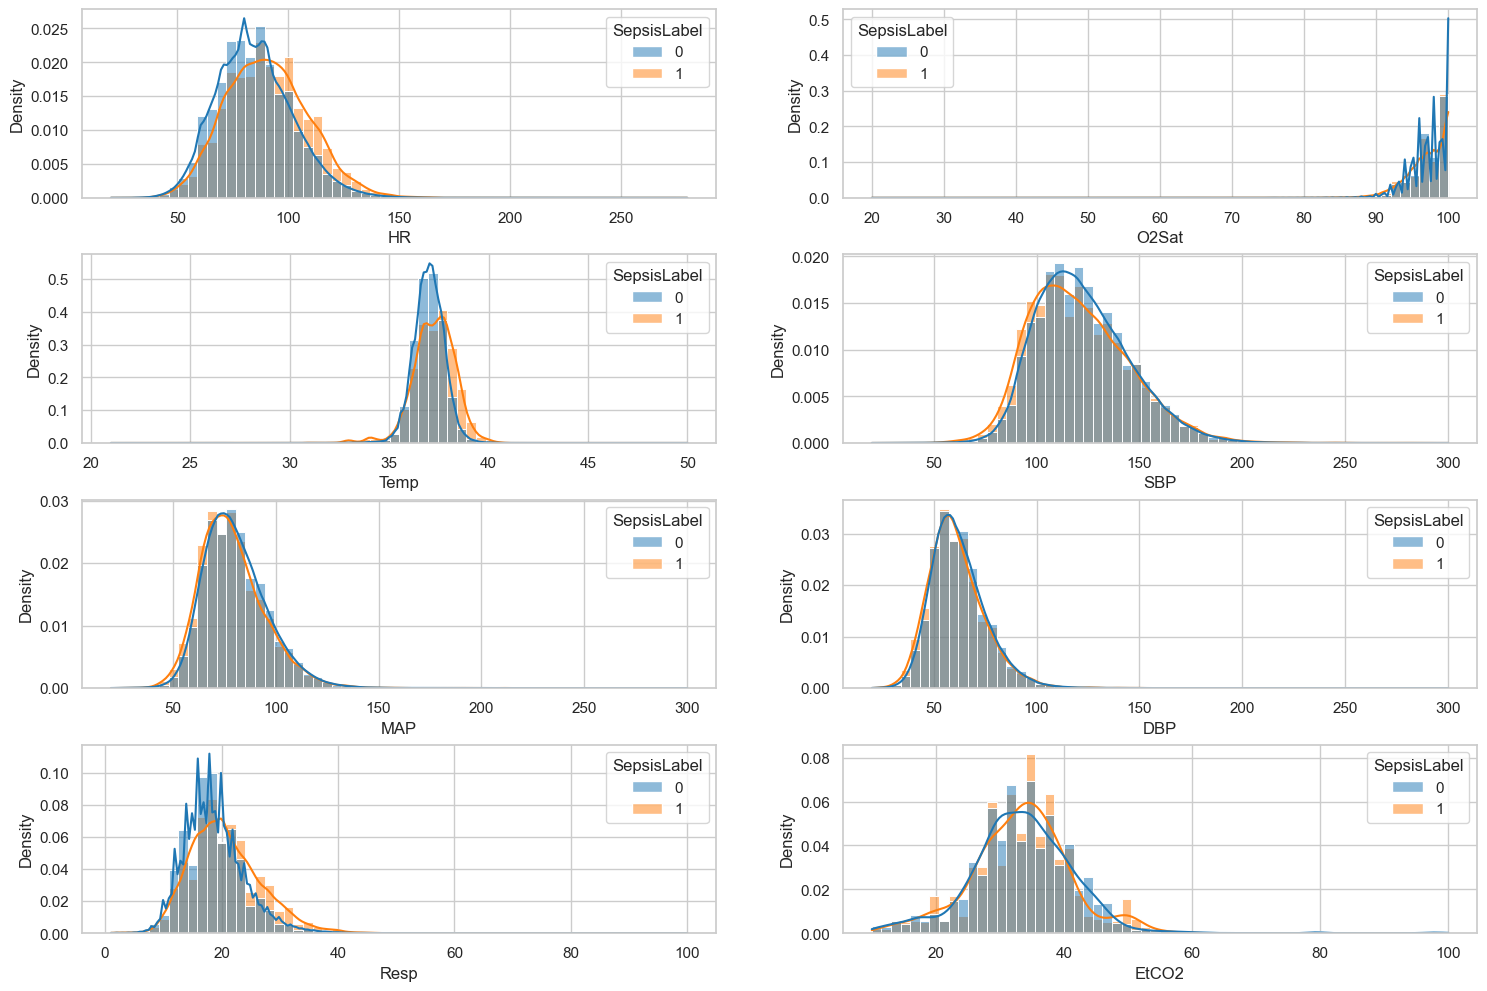

In [12]:
vital_signs = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]

plt.figure(figsize=(18,12))
plt.subplots_adjust(hspace = .3)
for i, column in enumerate(vital_signs, 1):
    plt.subplot(4,2,i)
    sns.histplot(data=X_train, x=column, hue=y_train, stat="density", common_norm=False, bins=60, kde=True)
plt.savefig("vital_signs.png", dpi=400)
plt.show()    

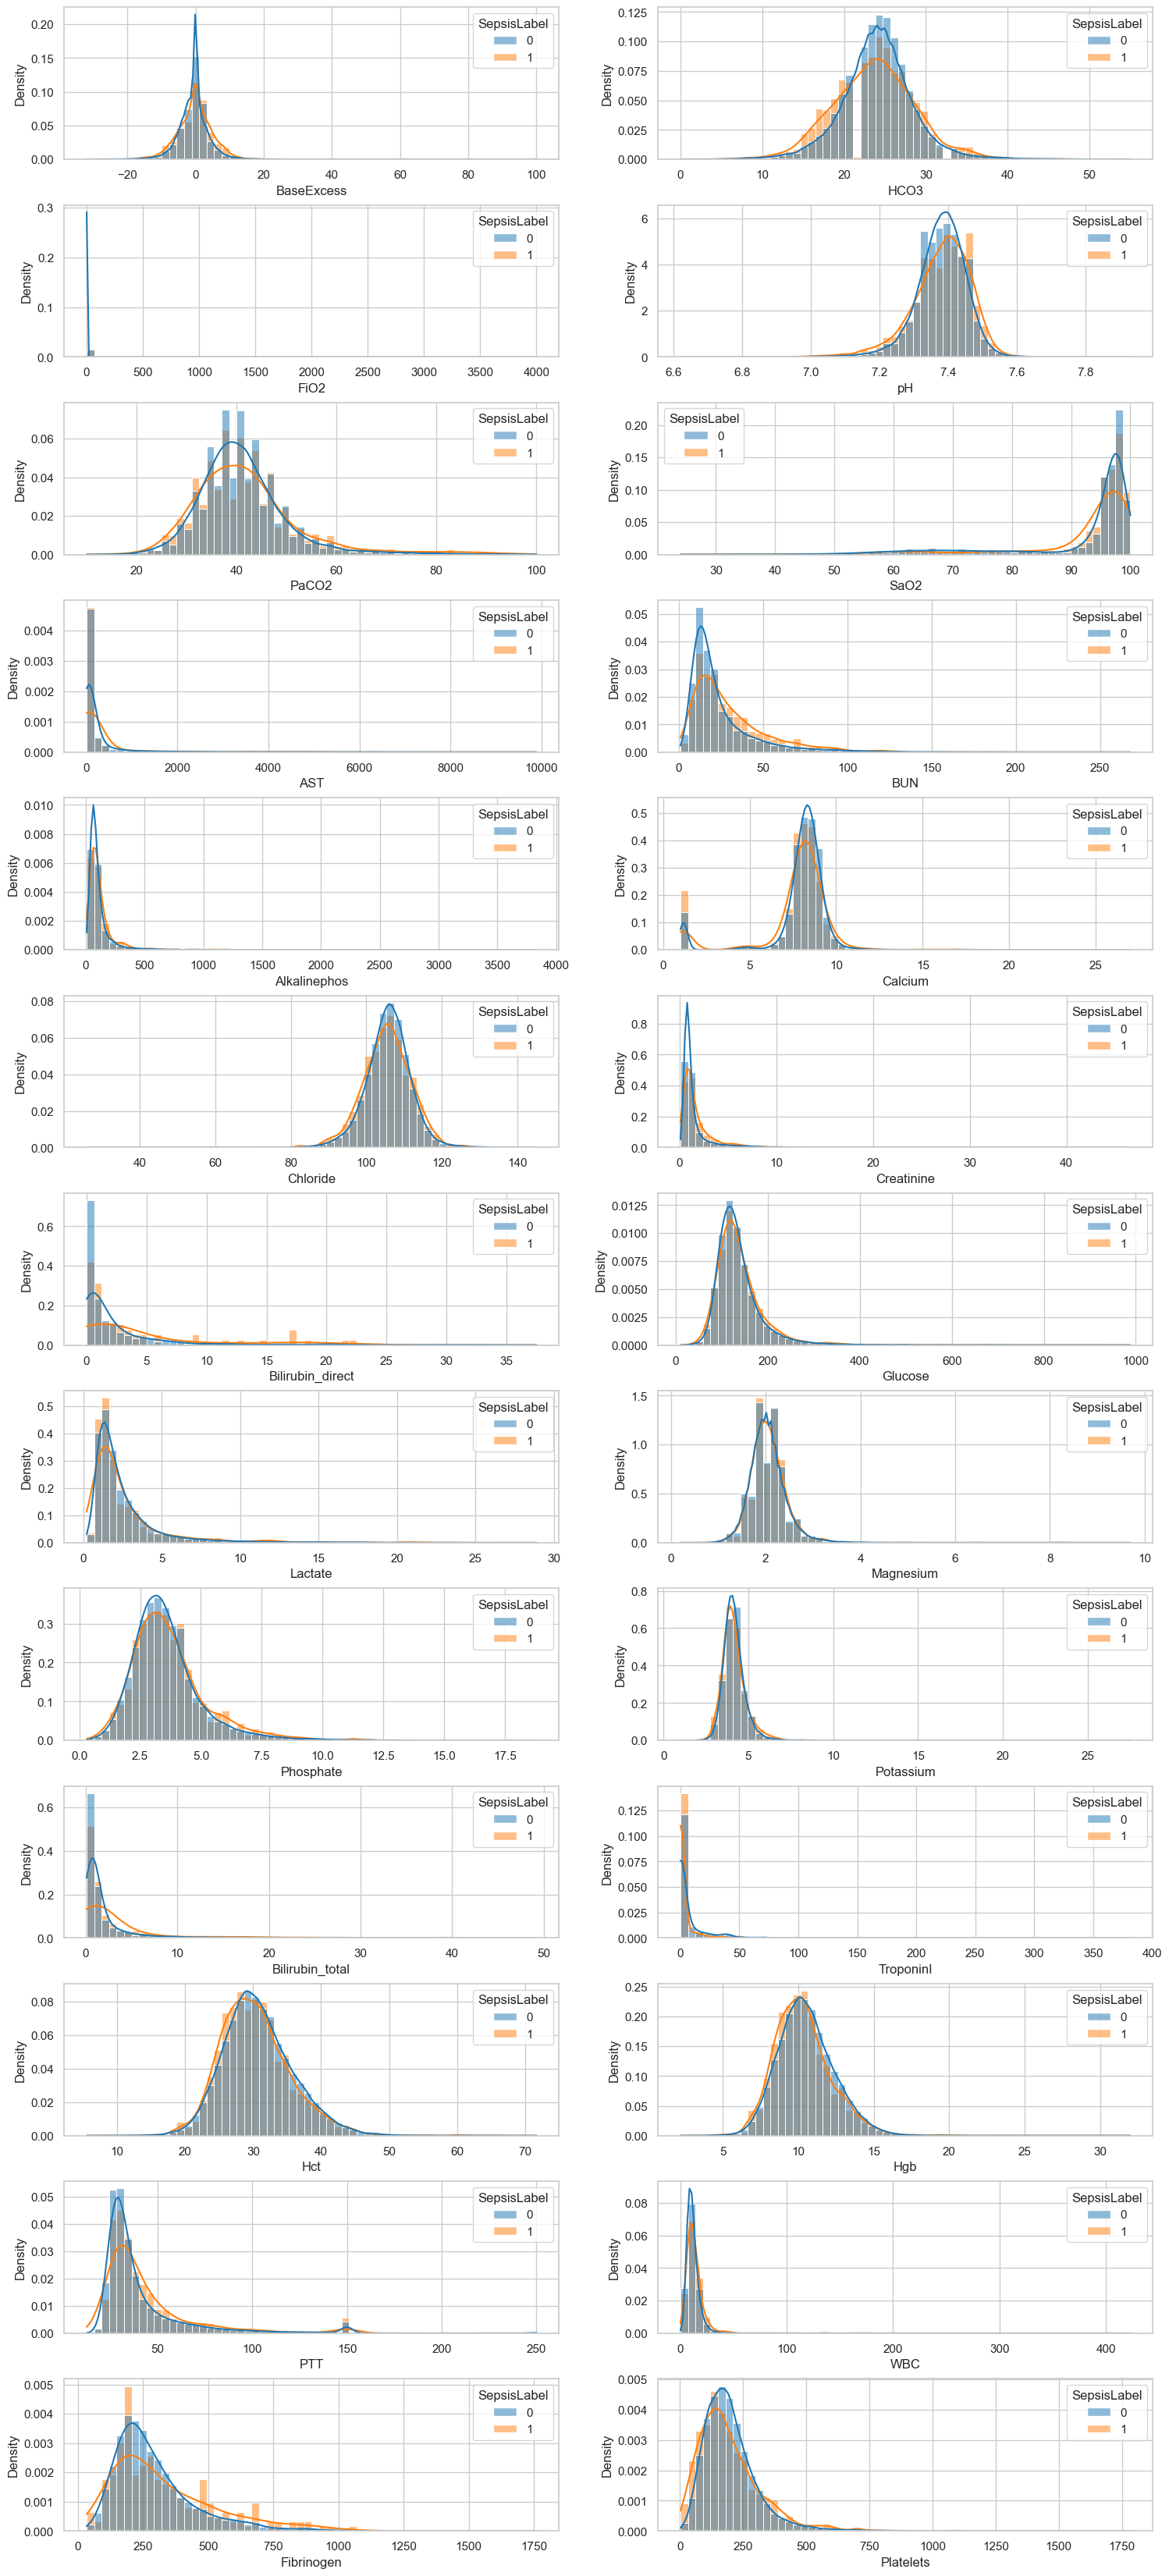

In [13]:
lab_values = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets']

plt.figure(figsize=(18,42))
plt.subplots_adjust(hspace = .3)
for i, column in enumerate(lab_values, 1):
    plt.subplot(13,2,i)
    sns.histplot(data=X_train, x=column, hue=y_train, stat="density", bins=60, common_norm=False, kde=True)
    
plt.savefig("lab_values.png", dpi=400)

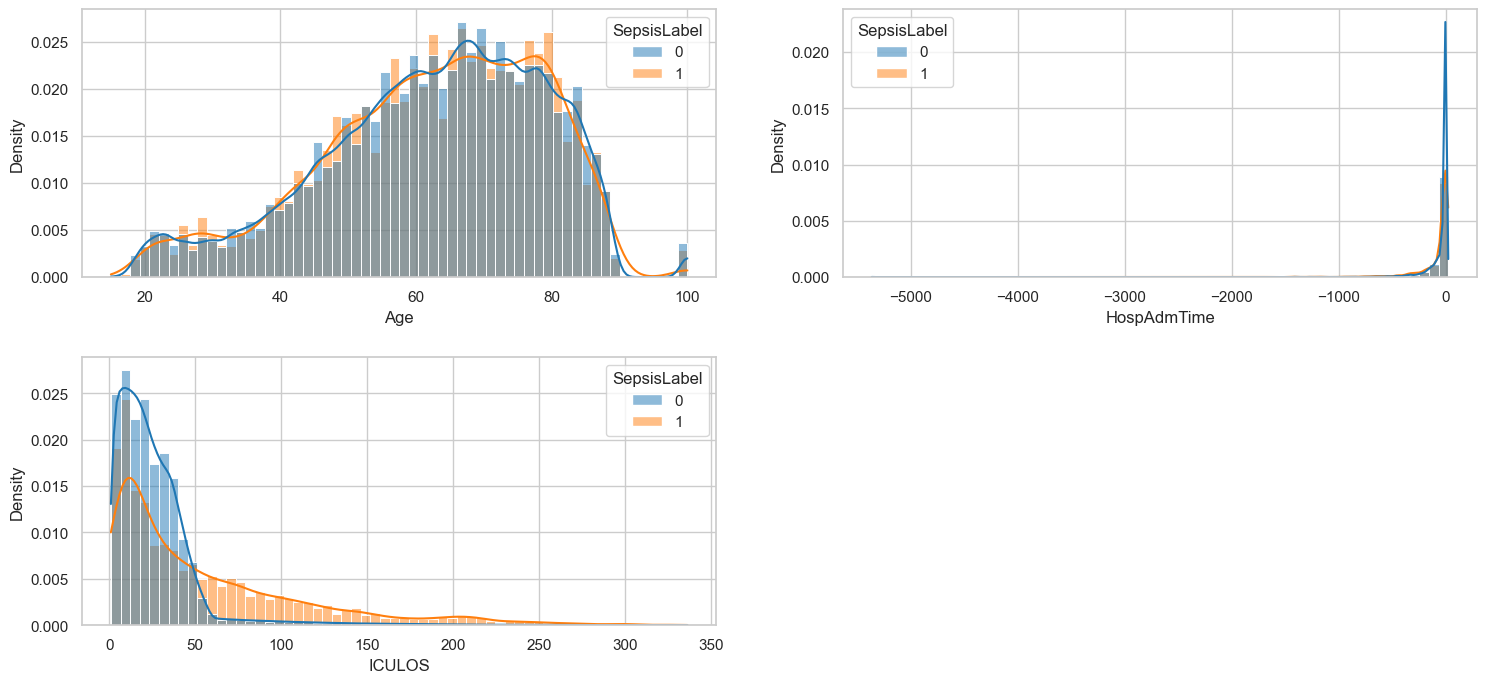

In [14]:
demographics = ["Age", "HospAdmTime", "ICULOS"]

plt.figure(figsize=(18,8))
plt.subplots_adjust(hspace = .3)
for i, column in enumerate(demographics, 1):
    plt.subplot(2,2,i)
    sns.histplot(data=X_train, x=column, hue=y_train, stat="density", bins=60, common_norm=False, kde=True)
    
plt.savefig("demographics.png", dpi=400)

In [15]:
def plotGender(data):
    gender = data.copy().astype("object")
    gender = gender.map({0: "female", 1: "male"})
    
    sns.countplot(x=gender, hue=y_train, dodge=False)

    
def plotUnit(data):
    Unit1 = data["Unit1"][data["Unit1"]==1].count() # patients in Unit1
    Unit2 = data["Unit2"][data["Unit2"]==1].count() # patients in Unit2
    totalNa = len(data["Unit1"][(data["Unit1"].isna()) & (data["Unit2"].isna())])
    
    sns.barplot(x=["Medical ICU","Surgical ICU","Not Given"] ,y=[Unit1, Unit2, totalNa])

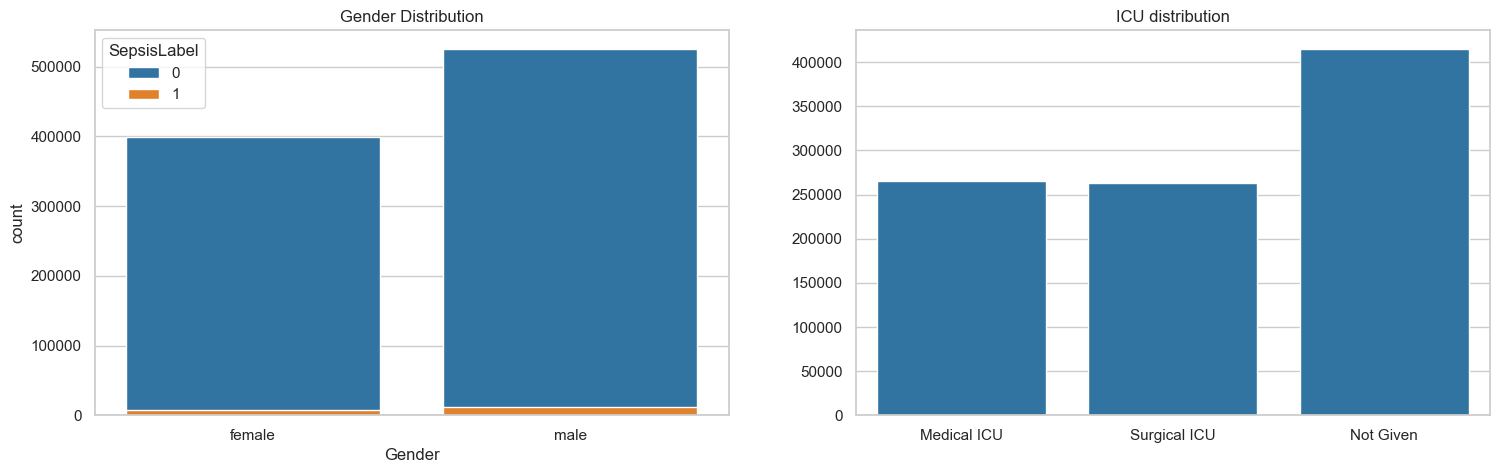

In [16]:
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.title("Gender Distribution")
plotGender(X_train["Gender"])   
plt.subplot(1,2,2)
plt.title("ICU distribution")
plotUnit(X_train)

plt.savefig("additional.png", dpi=400)

In [17]:
def CombineUnits(units_cols):
    data = units_cols.copy()
    data["Unit"] = pd.Series(np.zeros((len(data))))
    data.loc[data["Unit1"] == 1, "Unit"] = "MICU"
    data.loc[data["Unit2"] == 1, "Unit"] = "SICU"
    data.loc[(data["Unit1"].isna()) & (data["Unit2"].isna()), "Unit"] = "Other ICU"
    return data[["Unit"]]


def ShareSepticByUnit(UnitCol, y):
    shares = {}
    
    IsSepsis_micu = y.loc[UnitCol["Unit"] == "MICU"]
    IsSepsis_sicu = y.loc[UnitCol["Unit"] == "SICU"]
    IsSepsis_other = y.loc[UnitCol["Unit"] == "Other ICU"]
    
    shares["MICU"] = IsSepsis_micu[IsSepsis_micu == 1].count() / len(IsSepsis_micu) * 100
    shares["SICU"] = IsSepsis_sicu[IsSepsis_sicu == 1].count() / len(IsSepsis_sicu) * 100
    shares["Other"] = IsSepsis_other[IsSepsis_other == 1].count() / len(IsSepsis_other) * 100
        
    return shares


IsSeptic_shares = ShareSepticByUnit(CombineUnits(X_train.copy()), y_train)

C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


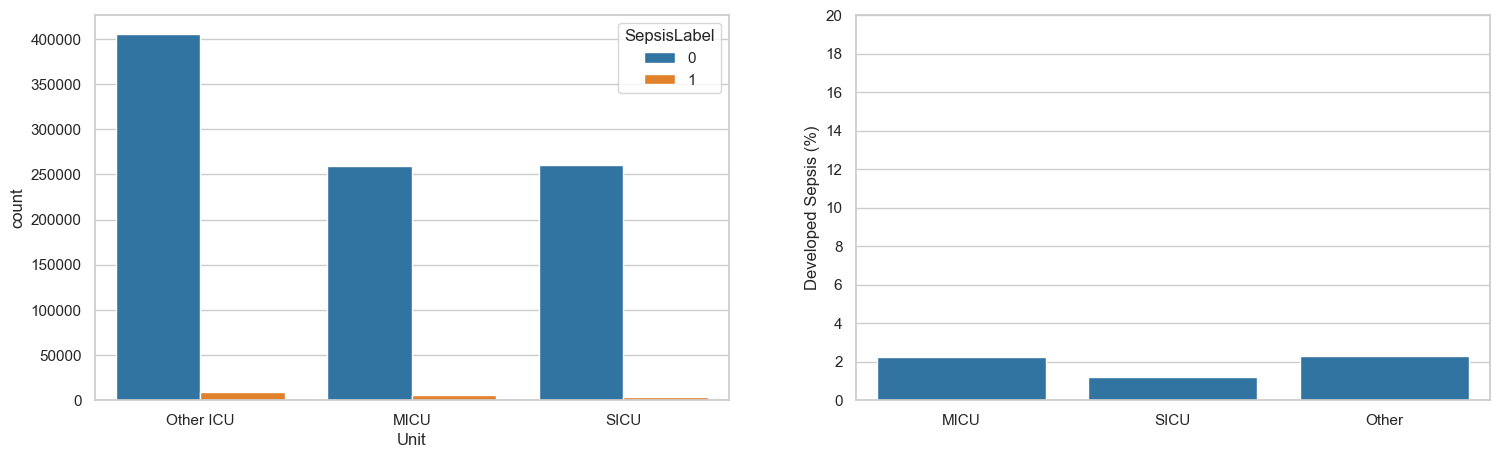

In [18]:
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
sns.countplot(data=CombineUnits(X_train.copy()), x="Unit", hue=y_train)
plt.subplot(1,2,2)
plt.ylim([0,20])
plt.ylabel("Developed Sepsis (%)")
plt.yticks([i for i in range(0,21,2)])
sns.barplot(x=list(IsSeptic_shares.keys()), y=list(IsSeptic_shares.values()))

plt.savefig("add2.png", dpi=400)

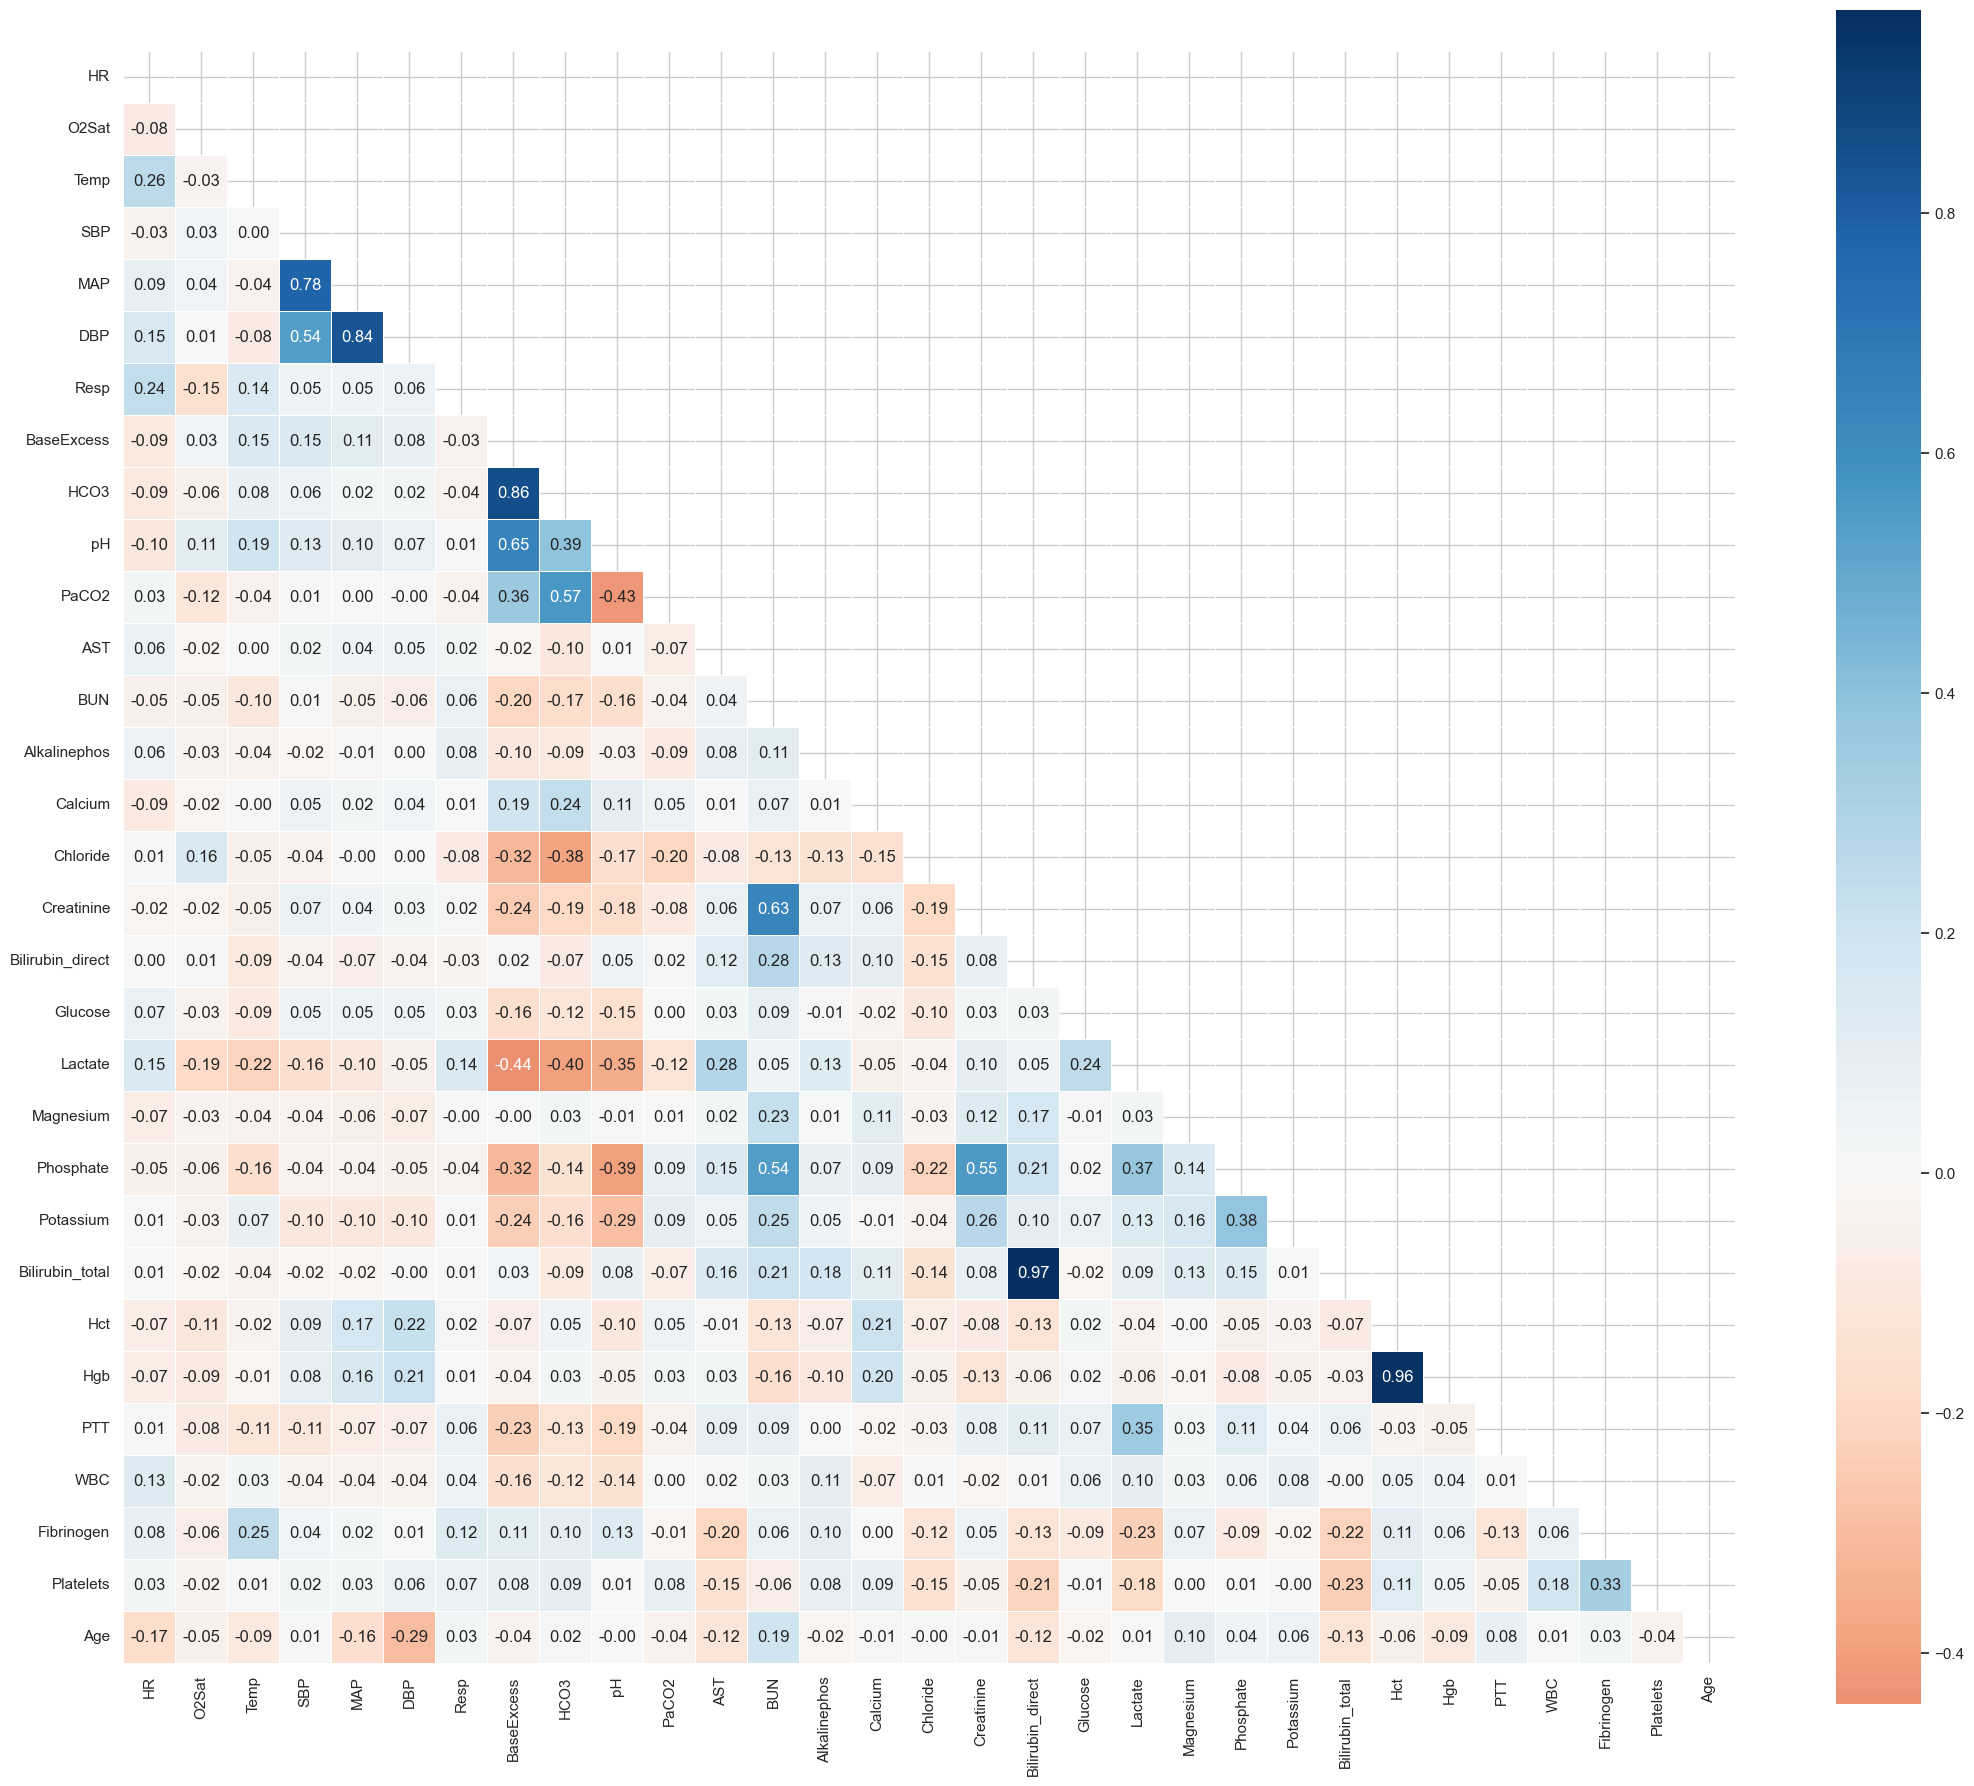

In [19]:
correlation_features = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "BaseExcess", "HCO3", "pH", "PaCO2", "AST",
                       "BUN", "Alkalinephos", "Calcium", "Chloride", "Creatinine", "Bilirubin_direct", "Glucose", "Lactate",
                       "Magnesium", "Phosphate", "Potassium", "Bilirubin_total", "Hct", "Hgb", "PTT", "WBC",
                       "Fibrinogen", "Platelets", "Age"]

mat_corr = X_train[correlation_features].corr()

mask = np.zeros_like(mat_corr)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(26,22))
sns.heatmap(mat_corr, mask=mask, square=True, annot=True, fmt=".2f", center=0, linewidths=.5, cmap="RdBu")

plt.savefig("cormat.png", dpi=400)

In [20]:
mat_corr["Bilirubin_total"].sort_values(ascending=False)[:3]


Bilirubin_total     1.000000
Bilirubin_direct    0.969441
BUN                 0.206118
Name: Bilirubin_total, dtype: float64

In [21]:
mat_corr["DBP"].sort_values(ascending=False)[:3]


DBP    1.000000
MAP    0.836746
SBP    0.539790
Name: DBP, dtype: float64

In [22]:
mat_corr["SBP"].sort_values(ascending=False)[:3]


SBP    1.00000
MAP    0.77698
DBP    0.53979
Name: SBP, dtype: float64

In [23]:
mat_corr["HCO3"].sort_values(ascending=False)[:4]


HCO3          1.000000
BaseExcess    0.856293
PaCO2         0.565006
pH            0.390058
Name: HCO3, dtype: float64

In [24]:
mat_corr["pH"].sort_values(ascending=False)[:4]
mat_corr["PaCO2"].sort_values(ascending=False)[:4]
mat_corr["Hgb"].sort_values(ascending=False)[:3]


Hgb    1.000000
Hct    0.956969
DBP    0.206539
Name: Hgb, dtype: float64

In [25]:
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer

X_train.columns
chi_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 
       'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'ICULOS']

X_chi = X_train[chi_cols].copy()

imputer = SimpleImputer(strategy="median")
X_chi[chi_cols] = imputer.fit_transform(X_chi)

chis = chi2(X_chi, y_train)

len(chi_cols)
chis[0].reshape(len(chi_cols),1)

chi_dict = {}
p_dict = {}
for i in range(len(chi_cols)):
    chi_dict[chi_cols[i]] = chis[0][i]
    p_dict[chi_cols[i]] = chis[1][i]

In [26]:
p_dict


{'HR': 0.0,
 'O2Sat': 0.02786113630872034,
 'Temp': 0.05987687858051454,
 'SBP': 9.109238958332512e-74,
 'MAP': 2.121933295448462e-103,
 'DBP': 4.0874791059884e-24,
 'Resp': 0.0,
 'EtCO2': 0.9029368516972823,
 'HCO3': 0.3790040321023793,
 'FiO2': 0.6185202455897056,
 'pH': 0.997999355189261,
 'PaCO2': 0.00028637383384571825,
 'SaO2': 0.36257977580899037,
 'AST': 0.0,
 'BUN': 2.2080301206783237e-103,
 'Alkalinephos': 2.800983035386236e-27,
 'Calcium': 0.13832328302245578,
 'Chloride': 0.6486370738538523,
 'Creatinine': 9.668156883149272e-05,
 'Bilirubin_direct': 0.17922481109369442,
 'Glucose': 4.498662704450917e-06,
 'Lactate': 0.0005898559128828732,
 'Magnesium': 0.8728388936060675,
 'Phosphate': 0.3951405159134166,
 'Potassium': 0.9668888322814448,
 'Bilirubin_total': 2.802827650589581e-10,
 'TroponinI': 1.2241263474789456e-07,
 'Hct': 0.31069386725533354,
 'Hgb': 0.41396044588231184,
 'PTT': 3.4652665473087935e-10,
 'WBC': 3.9612277385985175e-08,
 'Fibrinogen': 6.633502084774653e-08

In [27]:
X_train[X_train["Calcium"] < 2].head().T
X_train["Calcium"][X_train["Calcium"] < 2].count()


3112

In [28]:
X_train[X_train["PTT"] > 150].head().T


,970998,918563,902922,1040761,929219
S.No.,0.00,7.00,1.00,1.00,30.00
Hour,0.00,7.00,1.00,1.00,30.00
HR,107.00,68.00,127.00,70.00,89.00
O2Sat,99.00,77.00,100.00,100.00,99.00
Temp,34.20,31.80,NaN,NaN,NaN
SBP,136.00,64.00,120.00,111.00,119.00
MAP,87.00,65.50,82.00,54.00,98.00
DBP,44.00,59.00,66.00,81.00,83.00
Resp,20.00,NaN,NaN,10.00,18.00
EtCO2,26.00,14.00,NaN,NaN,NaN


In [29]:
X_train["Calcium"][X_train["PTT"] > 150].count()


40

In [30]:
y_train = y_train.loc[X_train["Age"] <= 90]
X_train = X_train.loc[X_train["Age"] <= 90]

y_test = y_test.loc[X_test["Age"] <= 90]
X_test = X_test.loc[X_test["Age"] <= 90]

def discretizateAge(data):
    # teen, youth, adult, senior
    bins = [13, 18, 30, 60, np.inf]
    data = np.digitize(data, bins=bins)
    data = data.reshape(len(data), 1)
    return data

DiscretizateAge = FunctionTransformer(discretizateAge)
DiscretizateAge.fit_transform(X_train["Age"]).shape

age_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("discretizator", DiscretizateAge)
])

age_pipeline.fit_transform(X_train[["Age"]]).shape

(938848, 1)

In [31]:
CombineAllUnits = FunctionTransformer(CombineUnits)

units = ["Unit1", "Unit2"]

units_pipeline = Pipeline([
    ("combine", CombineAllUnits),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

units_pipeline.fit_transform(X_train[units]).shape

C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


(938848, 3)

In [32]:
acidbase_features = ["BaseExcess", "PaCO2"]

def isAcidBaseDisturb(cols):
    cols = np.c_[cols, np.zeros(len(cols))]
    cols[:,2][(cols[:,0] < -2) & (cols[:,1] < 40)] = 1
    col = cols[:,2].reshape(len(cols), 1)
    return col

FindAcidosis = FunctionTransformer(isAcidBaseDisturb)
FindAcidosis.fit_transform(X_train[acidbase_features])

acidbase_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("acidosis", FindAcidosis)
])

acidbase_pipeline.fit_transform(X_train[acidbase_features]).shape

(938848, 1)

In [33]:
num_features = ["HR", "O2Sat", "Temp", "MAP", "Resp", "AST", "BUN",
                "Alkalinephos", "Calcium", "Creatinine", "Glucose", "Bilirubin_total", 
                "Hgb", "PTT", "WBC", "Fibrinogen", "Platelets", "ICULOS"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pipeline.fit_transform(X_train[num_features]).shape

(938848, 18)

In [34]:
gender_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

gender_pipeline.fit_transform(X_train[["Gender"]])

array([[0.],
       [1.],
       [0.],
       ...,
       [0.],
       [1.],
       [0.]])

In [35]:
preprocessing_pipeline = ColumnTransformer([
    ("numbers", num_pipeline, num_features),
    ("acidbase", acidbase_pipeline, acidbase_features),
    ("age", age_pipeline, ["Age"]),
    ("units", units_pipeline, units),
    ("gender", gender_pipeline, ["Gender"])
], verbose=True)

preprocessing_pipeline.fit_transform(X_train).shape

[ColumnTransformer] ....... (1 of 5) Processing numbers, total=   2.0s
[ColumnTransformer] ...... (2 of 5) Processing acidbase, total=   0.1s
[ColumnTransformer] ........... (3 of 5) Processing age, total=   0.1s


C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


[ColumnTransformer] ......... (4 of 5) Processing units, total=   0.2s
[ColumnTransformer] ........ (5 of 5) Processing gender, total=   0.1s


(938848, 24)

In [36]:
# Fit on train, transform both to avoid leakage
X_train = preprocessing_pipeline.fit_transform(X_train)
X_test = preprocessing_pipeline.transform(X_test)

[ColumnTransformer] ....... (1 of 5) Processing numbers, total=   2.0s
[ColumnTransformer] ...... (2 of 5) Processing acidbase, total=   0.1s
[ColumnTransformer] ........... (3 of 5) Processing age, total=   0.1s


C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


[ColumnTransformer] ......... (4 of 5) Processing units, total=   0.2s
[ColumnTransformer] ........ (5 of 5) Processing gender, total=   0.1s


C:\Users\lewin\AppData\Local\Temp\ipykernel_36540\2373916235.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MICU' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data["Unit1"] == 1, "Unit"] = "MICU"


In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score

xgboost = XGBClassifier(n_estimators=150, use_label_encoder=False, scale_pos_weight=12, eval_metric="aucpr", verbosity=1, disable_default_eval_metric=1)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score)
}

cv_xgboost = cross_validate(
    xgboost, X_train, y_train,
    cv=3,
    scoring=scoring,
    return_train_score=True,
    verbose=1
)

print(cv_xgboost)


c:\Users\lewin\Desktop\Projects\Sepsis Detection FYP\Sepsis-Detection\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [00:45:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\lewin\Desktop\Projects\Sepsis Detection FYP\Sepsis-Detection\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [00:45:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\lewin\Desktop\Projects\Sepsis Detection FYP\Sepsis-Detection\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [00:45:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'fit_time': array([1.78366852, 1.63605309, 1.59027958]), 'score_time': array([0.22506046, 0.18595243, 0.18365192]), 'test_accuracy': array([0.95088672, 0.9520465 , 0.95057342]), 'train_accuracy': array([0.95672618, 0.95742444, 0.9556462 ]), 'test_f1': array([0.19872797, 0.20778124, 0.20644367]), 'train_f1': array([0.30688129, 0.30647512, 0.3029603 ])}


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    6.6s finished


c:\Users\lewin\Desktop\Projects\Sepsis Detection FYP\Sepsis-Detection\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [00:45:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9477642685368821
XGBoost Confusion Matrix:
 [[98252  4010]
 [ 1442   669]]


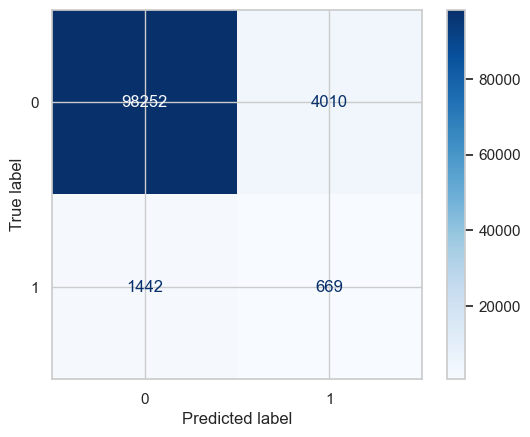

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train model
xgboost.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgboost.predict(X_test)

# Accuracy
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", acc_xgb)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n", cm_xgb)

# Optional: plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgboost.classes_)
disp.plot(cmap="Blues")
plt.show()


In [39]:
# !pip install imbalanced-learn

In [40]:
# Apply SMOTE on the training data only
from imblearn.over_sampling import SMOTE

# Estimate minority class proportion for k_neighbors safety
positive_count = int((y_train == 1).sum())

# Ensure k_neighbors is valid (< positive_count). Default is 5.
k_neighbors = 5 if positive_count > 6 else max(1, positive_count - 1)

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', np.bincount(y_train))
print('After  SMOTE:', np.bincount(y_train_res))


Before SMOTE: [920238  18610]
After  SMOTE: [920238 920238]


Resampled XGBoost Accuracy: 0.9606219999425138
Resampled Confusion Matrix:
 [[99923  2339]
 [ 1771   340]]
Recall (Negative=0): 0.977, Recall (Positive=1): 0.161
False Negatives: 1771
              precision    recall  f1-score   support

           0      0.983     0.977     0.980    102262
           1      0.127     0.161     0.142      2111

    accuracy                          0.961    104373
   macro avg      0.555     0.569     0.561    104373
weighted avg      0.965     0.961     0.963    104373



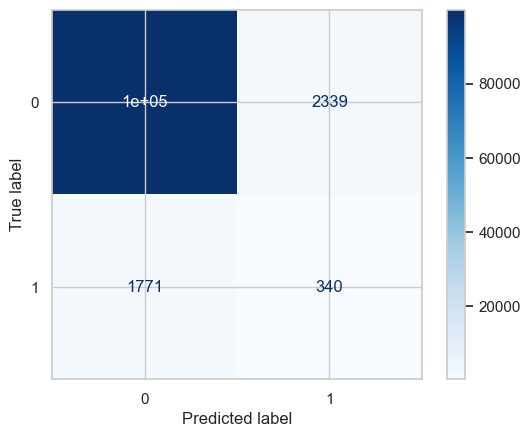

In [41]:
# Retrain XGBoost on resampled data
xgboost_res = XGBClassifier(n_estimators=150, scale_pos_weight=1, eval_metric="aucpr", verbosity=1, disable_default_eval_metric=1)

xgboost_res.fit(X_train_res, y_train_res)

y_pred_res = xgboost_res.predict(X_test)
acc_res = accuracy_score(y_test, y_pred_res)
print("Resampled XGBoost Accuracy:", acc_res)

cm_res = confusion_matrix(y_test, y_pred_res)
print("Resampled Confusion Matrix:\n", cm_res)

# Derive recall and false negatives explicitly
from sklearn.metrics import precision_recall_fscore_support, classification_report
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_res, average=None, labels=[0,1])
print(f"Recall (Negative=0): {recall[0]:.3f}, Recall (Positive=1): {recall[1]:.3f}")
false_negatives = cm_res[1,0]
print("False Negatives:", false_negatives)

print(classification_report(y_test, y_pred_res, digits=3))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_res, display_labels=xgboost_res.classes_)
disp.plot(cmap="Blues")
plt.show()


In [42]:
# # Build sequences per patient for LSTM
# import torch
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, confusion_matrix

# # Ensure Patient_ID and Hour exist
# assert 'Patient_ID' in dataSepsis.columns and 'Hour' in dataSepsis.columns, "Patient_ID/Hour required for sequencing"

# # Columns to use for LSTM (numeric + engineered outputs from earlier stages where feasible)
# sequence_feature_cols = num_features + acidbase_features + ['Age']  # already imputed/scaled previously

# # We need to rebuild preprocessing on the raw train/test splits but return arrays per row
# # Use the same fitted preprocessing_pipeline to transform original X_train/X_test row-wise.
# # For sequencing we will use raw frames with Patient_ID/Hour retained, so reconstruct X,y with those columns first

# # Recreate raw splits to retain IDs and Hour
# data_features = dataSepsis.drop('SepsisLabel', axis=1)
# labels = dataSepsis['SepsisLabel']
# X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(data_features, labels, test_size=0.1, random_state=42)

# # Filter age <= 90 as earlier
# mask_train_age = X_train_raw['Age'] <= 90
# mask_test_age = X_test_raw['Age'] <= 90
# X_train_raw, y_train_raw = X_train_raw.loc[mask_train_age], y_train_raw.loc[mask_train_age]
# X_test_raw, y_test_raw = X_test_raw.loc[mask_test_age], y_test_raw.loc[mask_test_age]

# # Fit-transform preprocessing on training, transform test (consistent with earlier)
# X_train_proc = preprocessing_pipeline.fit_transform(X_train_raw)
# X_test_proc = preprocessing_pipeline.transform(X_test_raw)

# # Persist feature matrix as numpy arrays
# X_train_proc = np.asarray(X_train_proc)
# X_test_proc = np.asarray(X_test_proc)

# # For mapping back Patient_ID/Hour, capture them from raw
# train_ids = X_train_raw['Patient_ID'].values
# train_hours = X_train_raw['Hour'].values

# test_ids = X_test_raw['Patient_ID'].values
# test_hours = X_test_raw['Hour'].values

# # Build index per patient -> list of (hour, row_index)
# from collections import defaultdict

# def build_patient_indices(ids, hours):
#     pid_to_indices = defaultdict(list)
#     for idx, (pid, hr) in enumerate(zip(ids, hours)):
#         pid_to_indices[pid].append((hr, idx))
#     # sort by hour within patient
#     for pid in pid_to_indices:
#         pid_to_indices[pid].sort(key=lambda t: t[0])
#     return pid_to_indices

# train_pid_to_idx = build_patient_indices(train_ids, train_hours)
# test_pid_to_idx = build_patient_indices(test_ids, test_hours)

# # Assemble sequences (variable length) and labels per time-step
# # For label we will use the row-level SepsisLabel aligned to each timestep

# y_train_arr = y_train_raw.values.astype(np.int64)
# y_test_arr = y_test_raw.values.astype(np.int64)

# train_sequences = []  # list of (T, F) arrays
# train_labels = []     # list of (T,) arrays
# for pid, pairs in train_pid_to_idx.items():
#     row_indices = [i for _, i in pairs]
#     seq_feat = X_train_proc[row_indices]
#     seq_labels = y_train_arr[row_indices]
#     train_sequences.append(seq_feat)
#     train_labels.append(seq_labels)

# test_sequences = []
# test_labels = []
# for pid, pairs in test_pid_to_idx.items():
#     row_indices = [i for _, i in pairs]
#     seq_feat = X_test_proc[row_indices]
#     seq_labels = y_test_arr[row_indices]
#     test_sequences.append(seq_feat)
#     test_labels.append(seq_labels)

# # Pad sequences for batching
# class SeqDataset(Dataset):
#     def __init__(self, sequences, labels):
#         self.sequences = sequences
#         self.labels = labels
#     def __len__(self):
#         return len(self.sequences)
#     def __getitem__(self, idx):
#         x = torch.tensor(self.sequences[idx], dtype=torch.float32)
#         y = torch.tensor(self.labels[idx], dtype=torch.long)
#         return x, y

# def collate_pad(batch):
#     # batch: list of (x: [T,F], y:[T])
#     lengths = [item[0].shape[0] for item in batch]
#     max_len = max(lengths)
#     feat_dim = batch[0][0].shape[1]
#     x_padded = torch.zeros(len(batch), max_len, feat_dim, dtype=torch.float32)
#     y_padded = torch.full((len(batch), max_len), -100, dtype=torch.long)  # ignore index
#     mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
#     for i, (x, y) in enumerate(batch):
#         T = x.shape[0]
#         x_padded[i, :T] = x
#         y_padded[i, :T] = y
#         mask[i, :T] = 1
#     return x_padded, y_padded, mask

# train_ds = SeqDataset(train_sequences, train_labels)
# test_ds = SeqDataset(test_sequences, test_labels)

# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_pad)
# test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_pad)

# # Define LSTM model
# class LSTMSepsis(nn.Module):
#     def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, bidirectional=False):
#         super().__init__()
#         self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers,
#                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
#                             bidirectional=bidirectional)
#         self.bidirectional = bidirectional
#         out_dim = hidden_dim * (2 if bidirectional else 1)
#         self.dropout = nn.Dropout(p=dropout)
#         self.classifier = nn.Linear(out_dim, 2)
#     def forward(self, x, lengths):
#         # x: [B, T, F]
#         packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
#         packed_out, _ = self.lstm(packed)
#         out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
#         out = self.dropout(out)
#         logits = self.classifier(out)  # [B,T,2]
#         return logits

# input_dim = X_train_proc.shape[1]
# model = LSTMSepsis(input_dim=input_dim)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)

# # Class weights for severe imbalance using training labels
# # Compute per-time-step class counts
# all_train_y = np.concatenate(train_labels)
# class_counts = np.bincount(all_train_y, minlength=2)
# weights = class_counts.sum() / (2.0 * np.maximum(class_counts, 1))
# class_weights = torch.tensor(weights, dtype=torch.float32, device=device)

# criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # Training loop
# def train_epoch(model, loader):
#     model.train()
#     total_loss = 0.0
#     total_tokens = 0
#     for xb, yb, mask in loader:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         optimizer.zero_grad()
#         logits = model(xb, lengths)  # [B,T,2]
#         loss = criterion(logits.view(-1, 2), yb.view(-1))
#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         num_tok = (yb != -100).sum().item()
#         total_loss += loss.item() * num_tok
#         total_tokens += num_tok
#     return total_loss / max(1, total_tokens)

# @torch.no_grad()
# def eval_epoch(model, loader):
#     model.eval()
#     total_loss = 0.0
#     total_tokens = 0
#     all_preds = []
#     all_true = []
#     for xb, yb, mask in loader:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         logits = model(xb, lengths)
#         loss = criterion(logits.view(-1, 2), yb.view(-1))
#         num_tok = (yb != -100).sum().item()
#         total_loss += loss.item() * num_tok
#         total_tokens += num_tok
#         preds = logits.argmax(dim=-1)
#         valid = yb != -100
#         all_preds.append(preds[valid].detach().cpu().numpy())
#         all_true.append(yb[valid].detach().cpu().numpy())
#     if len(all_preds):
#         all_preds = np.concatenate(all_preds)
#         all_true = np.concatenate(all_true)
#         report = classification_report(all_true, all_preds, digits=3, output_dict=False)
#     else:
#         report = "No predictions"
#     return total_loss / max(1, total_tokens), report

# num_epochs = 5
# for epoch in range(1, num_epochs+1):
#     tr_loss = train_epoch(model, train_loader)
#     va_loss, va_report = eval_epoch(model, test_loader)
#     print(f"Epoch {epoch}: train_loss={tr_loss:.5f} val_loss={va_loss:.5f}")
#     print(va_report)

# # Confusion matrix on flattened tokens
# @torch.no_grad()
# def compute_confusion(model, loader):
#     model.eval()
#     ys = []
#     ps = []
#     for xb, yb, mask in loader:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         logits = model(xb, lengths)
#         preds = logits.argmax(dim=-1)
#         valid = yb != -100
#         ys.append(yb[valid].detach().cpu().numpy())
#         ps.append(preds[valid].detach().cpu().numpy())
#     ys = np.concatenate(ys)
#     ps = np.concatenate(ps)
#     cm = confusion_matrix(ys, ps)
#     return cm

# cm_lstm = compute_confusion(model, test_loader)
# print("LSTM Confusion Matrix:\n", cm_lstm)



In [43]:
# # Validation split, metrics, focal loss, and CNN+BiLSTM model
# import math
# from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# # Build patient id lists
# train_pids = list(train_pid_to_idx.keys())

# # Patient-wise validation split
# rng = np.random.default_rng(42)
# val_ratio = 0.15
# num_val = max(1, int(len(train_pids) * val_ratio))
# val_pids = set(rng.choice(train_pids, size=num_val, replace=False))

# train_seq_tr, train_lab_tr = [], []
# val_seq, val_lab = [], []
# for pid, pairs in train_pid_to_idx.items():
#     row_indices = [i for _, i in pairs]
#     seq_feat = X_train_proc[row_indices]
#     seq_labels = y_train_arr[row_indices]
#     if pid in val_pids:
#         val_seq.append(seq_feat)
#         val_lab.append(seq_labels)
#     else:
#         train_seq_tr.append(seq_feat)
#         train_lab_tr.append(seq_labels)

# train_ds_tr = SeqDataset(train_seq_tr, train_lab_tr)
# val_ds = SeqDataset(val_seq, val_lab)

# train_loader_tr = DataLoader(train_ds_tr, batch_size=64, shuffle=True, collate_fn=collate_pad)
# val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_pad)

# # Focal loss to combat class imbalance
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=None, gamma=2.0, ignore_index=-100, reduction='mean'):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.ignore_index = ignore_index
#         self.reduction = reduction
#         self.ce_base = nn.CrossEntropyLoss(weight=alpha, reduction='none')
#     def forward(self, logits, target):
#         valid = (target != self.ignore_index)
#         if not torch.any(valid):
#             return torch.zeros((), device=logits.device, dtype=logits.dtype)
#         target = target.long()
#         logits_v = logits[valid]
#         target_v = target[valid]
#         # Ensure CE loss weight is on same device
#         if hasattr(self.ce_base, 'weight') and self.ce_base.weight is not None and self.ce_base.weight.device != logits_v.device:
#             self.ce_base.weight = self.ce_base.weight.to(logits_v.device)
#         # Extra guard: ensure labels are in range [0, C-1]
#         C = logits_v.size(-1)
#         if (target_v < 0).any() or (target_v >= C).any():
#             bad_min = int(target_v.min().item())
#             bad_max = int(target_v.max().item())
#             raise RuntimeError(f"Targets out of range for CE: min={bad_min}, max={bad_max}, C={C}")
#         ce = self.ce_base(logits_v, target_v)
#         with torch.no_grad():
#             probs = torch.softmax(logits_v, dim=-1)
#             true_probs = probs.gather(-1, target_v.unsqueeze(-1)).squeeze(-1)
#             true_probs = torch.clamp(true_probs, 1e-6, 1-1e-6)
#         focal = (1.0 - true_probs) ** self.gamma * ce
#         if self.reduction == 'mean':
#             return focal.mean()
#         elif self.reduction == 'sum':
#             return focal.sum()
#         else:
#             return focal

# # CNN+BiLSTM model (Temporal conv + BiLSTM + classifier)
# class CNNBiLSTM(nn.Module):
#     def __init__(self, input_dim, conv_channels=64, kernel_size=5, lstm_hidden=128, num_layers=2, dropout=0.2):
#         super().__init__()
#         padding = kernel_size // 2
#         self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=conv_channels, kernel_size=kernel_size, padding=padding)
#         self.bn1 = nn.BatchNorm1d(conv_channels)
#         self.relu = nn.ReLU(inplace=True)
#         self.dropout = nn.Dropout(p=dropout)
#         self.bilstm = nn.LSTM(input_size=conv_channels, hidden_size=lstm_hidden, num_layers=num_layers,
#                               batch_first=True, dropout=dropout if num_layers > 1 else 0.0, bidirectional=True)
#         self.classifier = nn.Linear(lstm_hidden * 2, 2)
#     def forward(self, x, lengths):
#         # x: [B,T,F] -> conv expects [B,F,T]
#         x = x.transpose(1, 2)
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.dropout(x)
#         x = x.transpose(1, 2)  # [B,T,C]
#         packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
#         packed_out, _ = self.bilstm(packed)
#         out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
#         out = self.dropout(out)
#         logits = self.classifier(out)
#         return logits

# # Recompute class weights on training tokens only
# all_train_tokens = np.concatenate(train_lab_tr) if len(train_lab_tr) else np.array([0,1])
# class_counts_tr = np.bincount(all_train_tokens, minlength=2)
# weights_tr = class_counts_tr.sum() / (2.0 * np.maximum(class_counts_tr, 1))
# alpha = torch.tensor(weights_tr, dtype=torch.float32)

# model2 = CNNBiLSTM(input_dim=input_dim)
# model2 = model2.to(device)
# alpha = alpha.to(device)

# criterion2 = FocalLoss(alpha=alpha, gamma=2.0, ignore_index=-100)
# optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
# scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=2, verbose=True)

# best_val_loss = float('inf')
# best_state = None
# patience = 5
# stale = 0
# max_epochs = 15

# for epoch in range(1, max_epochs+1):
#     # Train
#     model2.train()
#     total_loss = 0.0
#     total_tokens = 0
#     for xb, yb, mask in train_loader_tr:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         optimizer2.zero_grad()
#         logits = model2(xb, lengths)
#         valid = (yb != -100)
#         yv = yb[valid].long()
#         if yv.numel() > 0:
#             y_min = int(yv.min().item())
#             y_max = int(yv.max().item())
#             if y_min < 0 or y_max > 1:
#                 raise RuntimeError(f"Training targets out of range: min={y_min}, max={y_max}")
#         loss = criterion2(logits.view(-1, 2), yb.view(-1))
#         loss.backward()
#         nn.utils.clip_grad_norm_(model2.parameters(), max_norm=1.0)
#         optimizer2.step()
#         total_loss += loss.item() * valid.sum().item()
#         total_tokens += valid.sum().item()
#     train_loss = total_loss / max(1, total_tokens)

#     # Validate
#     model2.eval()
#     v_total_loss = 0.0
#     v_total_tokens = 0
#     v_true = []
#     v_prob1 = []
#     with torch.no_grad():
#         for xb, yb, mask in val_loader:
#             lengths = mask.sum(dim=1)
#             xb = xb.to(device)
#             yb = yb.to(device)
#             lengths = lengths.to(device)
#             logits = model2(xb, lengths)
#             valid = (yb != -100)
#             yv = yb[valid].long()
#             if yv.numel() > 0:
#                 y_min = int(yv.min().item())
#                 y_max = int(yv.max().item())
#                 if y_min < 0 or y_max > 1:
#                     raise RuntimeError(f"Validation targets out of range: min={y_min}, max={y_max}")
#             loss = criterion2(logits.view(-1, 2), yb.view(-1))
#             v_total_loss += loss.item() * valid.sum().item()
#             v_total_tokens += valid.sum().item()
#             probs = torch.softmax(logits, dim=-1)[...,1]
#             v_prob1.append(probs[valid].detach().cpu().numpy())
#             v_true.append(yb[valid].detach().cpu().numpy())
#     val_loss = v_total_loss / max(1, v_total_tokens)
#     scheduler2.step(val_loss)

#     v_prob1 = np.concatenate(v_prob1) if len(v_prob1) else np.array([0.0])
#     v_true = np.concatenate(v_true) if len(v_true) else np.array([0])
#     val_ap = average_precision_score(v_true, v_prob1) if v_true.size > 1 and np.unique(v_true).size > 1 else float('nan')
#     print(f"Epoch {epoch}: train_loss={train_loss:.5f} val_loss={val_loss:.5f} val_AP={val_ap:.4f}")

#     if val_loss + 1e-6 < best_val_loss:
#         best_val_loss = val_loss
#         best_state = {k: v.detach().cpu().clone() for k, v in model2.state_dict().items()}
#         stale = 0
#     else:
#         stale += 1
#         if stale >= patience:
#             print("Early stopping.")
#             break

# # Load best weights
# if best_state is not None:
#     model2.load_state_dict(best_state)

# # Threshold tuning on validation for F1
# val_true_all, val_prob_all = [], []
# model2.eval()
# with torch.no_grad():
#     for xb, yb, mask in val_loader:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         logits = model2(xb, lengths)
#         probs = torch.softmax(logits, dim=-1)[...,1]
#         valid = (yb != -100)
#         val_prob_all.append(probs[valid].detach().cpu().numpy())
#         val_true_all.append(yb[valid].detach().cpu().numpy())
# val_true_all = np.concatenate(val_true_all) if len(val_true_all) else np.array([0])
# val_prob_all = np.concatenate(val_prob_all) if len(val_prob_all) else np.array([0.0])

# best_thresh = 0.5
# best_f1 = -1.0
# if val_true_all.size > 1 and np.unique(val_true_all).size > 1:
#     prec, rec, thr = precision_recall_curve(val_true_all, val_prob_all)
#     for t in np.unique(np.concatenate([thr, np.array([0.5])])):
#         pred = (val_prob_all >= t).astype(int)
#         f1 = f1_score(val_true_all, pred)
#         if f1 > best_f1:
#             best_f1 = f1
#             best_thresh = t
# print(f"Selected threshold: {best_thresh:.3f} (val F1={best_f1:.3f})")

# # Evaluate on test set with tuned threshold
# te_true_all, te_prob_all = [], []
# with torch.no_grad():
#     for xb, yb, mask in test_loader:
#         lengths = mask.sum(dim=1)
#         xb = xb.to(device)
#         yb = yb.to(device)
#         lengths = lengths.to(device)
#         logits = model2(xb, lengths)
#         probs = torch.softmax(logits, dim=-1)[...,1]
#         valid = (yb != -100)
#         te_prob_all.append(probs[valid].detach().cpu().numpy())
#         te_true_all.append(yb[valid].detach().cpu().numpy())
# te_true_all = np.concatenate(te_true_all)
# te_prob_all = np.concatenate(te_prob_all)

# te_pred = (te_prob_all >= best_thresh).astype(int)
# print(classification_report(te_true_all, te_pred, digits=3))
# cm_cnn_lstm = confusion_matrix(te_true_all, te_pred)
# print("CNN+BiLSTM Confusion Matrix:\n", cm_cnn_lstm)



In [44]:
# # GRU-D: build masks/deltas and model
# # We will use raw train/test splits (X_train_raw, X_test_raw) and labels y_train_arr/y_test_arr
# # Features for GRU-D will be the same numeric/engineered set used earlier where available

# # Choose a numeric feature set present in raw data (avoid engineered units/gender encodings here)
# grud_features = [
#     'HR','O2Sat','Temp','SBP','MAP','DBP','Resp','EtCO2','BaseExcess','HCO3','FiO2','pH','PaCO2','SaO2',
#     'AST','BUN','Alkalinephos','Calcium','Chloride','Creatinine','Bilirubin_direct','Glucose','Lactate',
#     'Magnesium','Phosphate','Potassium','Bilirubin_total','TroponinI','Hct','Hgb','PTT','WBC','Fibrinogen','Platelets',
#     'Age','ICULOS'
# ]
# # Keep only columns that exist
# grud_features = [c for c in grud_features if c in X_train_raw.columns]

# # Compute training feature means (ignoring NaNs)
# feat_means = X_train_raw[grud_features].mean(axis=0).values.astype(np.float32)
# feat_means_t = torch.tensor(feat_means, dtype=torch.float32)

# # Helper to assemble sequences of (X, M, Delta, y) per patient
# def build_grud_sequences(X_raw, y_raw, pid_to_idx):
#     seq_X, seq_M, seq_D, seq_y = [], [], [], []
#     for pid, pairs in pid_to_idx.items():
#         idxs = [i for _, i in pairs]
#         dfp = X_raw.iloc[idxs]
#         hrs = dfp['Hour'].values.astype(np.float32)
#         # feature matrix with NaNs preserved
#         Xf = dfp[grud_features].to_numpy().astype(np.float32)
#         M = (~np.isnan(Xf)).astype(np.float32)
#         # Deltas based on hour gaps; first delta is zero
#         if len(hrs) > 1:
#             d = np.diff(hrs, prepend=hrs[0])
#         else:
#             d = np.array([0.0], dtype=np.float32)
#         # broadcast per feature
#         D = np.repeat(d.reshape(-1,1), len(grud_features), axis=1).astype(np.float32)
#         # Labels in same order
#         yseq = y_raw.iloc[idxs].values.astype(np.int64)
#         seq_X.append(Xf)
#         seq_M.append(M)
#         seq_D.append(D)
#         seq_y.append(yseq)
#     return seq_X, seq_M, seq_D, seq_y

# train_Xg, train_Mg, train_Dg, train_yg = build_grud_sequences(X_train_raw, y_train_raw, train_pid_to_idx)
# test_Xg, test_Mg, test_Dg, test_yg = build_grud_sequences(X_test_raw, y_test_raw, test_pid_to_idx)

# # Split validation as before using val_pids
# val_pids = val_pids if 'val_pids' in globals() else set()
# train_Xg_tr, train_Mg_tr, train_Dg_tr, train_yg_tr = [], [], [], []
# val_Xg, val_Mg, val_Dg, val_yg = [], [], [], []
# for pid, pairs in train_pid_to_idx.items():
#     idxs = [i for _, i in pairs]
#     # find matching sequence index by iterating in same order
#     # Recompute once to avoid mismatch
#     dfp = X_train_raw.iloc[idxs]
#     hrs = dfp['Hour'].values.astype(np.float32)
#     Xf = dfp[grud_features].to_numpy().astype(np.float32)
#     M = (~np.isnan(Xf)).astype(np.float32)
#     if len(hrs) > 1:
#         d = np.diff(hrs, prepend=hrs[0])
#     else:
#         d = np.array([0.0], dtype=np.float32)
#     D = np.repeat(d.reshape(-1,1), len(grud_features), axis=1).astype(np.float32)
#     yseq = y_train_raw.iloc[idxs].values.astype(np.int64)
#     if pid in val_pids:
#         val_Xg.append(Xf); val_Mg.append(M); val_Dg.append(D); val_yg.append(yseq)
#     else:
#         train_Xg_tr.append(Xf); train_Mg_tr.append(M); train_Dg_tr.append(D); train_yg_tr.append(yseq)

# class GRUDDataset(Dataset):
#     def __init__(self, X_list, M_list, D_list, y_list):
#         self.X = X_list; self.M = M_list; self.D = D_list; self.Y = y_list
#     def __len__(self):
#         return len(self.X)
#     def __getitem__(self, idx):
#         return (
#             torch.tensor(self.X[idx], dtype=torch.float32),
#             torch.tensor(self.M[idx], dtype=torch.float32),
#             torch.tensor(self.D[idx], dtype=torch.float32),
#             torch.tensor(self.Y[idx], dtype=torch.long)
#         )

# def collate_grud(batch):
#     lens = [b[0].shape[0] for b in batch]
#     T = max(lens)
#     F = batch[0][0].shape[1]
#     B = len(batch)
#     Xp = torch.zeros(B, T, F)
#     Mp = torch.zeros(B, T, F)
#     Dp = torch.zeros(B, T, F)
#     Yp = torch.full((B, T), -100, dtype=torch.long)
#     mask = torch.zeros(B, T, dtype=torch.bool)
#     for i,(X,M,D,Y) in enumerate(batch):
#         L = X.shape[0]
#         Xp[i,:L] = X
#         Mp[i,:L] = M
#         Dp[i,:L] = D
#         Yp[i,:L] = Y
#         mask[i,:L] = 1
#     return Xp, Mp, Dp, Yp, mask

# train_grud_ds = GRUDDataset(train_Xg_tr, train_Mg_tr, train_Dg_tr, train_yg_tr)
# val_grud_ds = GRUDDataset(val_Xg, val_Mg, val_Dg, val_yg)
# test_grud_ds = GRUDDataset(test_Xg, test_Mg, test_Dg, test_yg)

# train_grud_loader = DataLoader(train_grud_ds, batch_size=64, shuffle=True, collate_fn=collate_grud)
# val_grud_loader = DataLoader(val_grud_ds, batch_size=64, shuffle=False, collate_fn=collate_grud)
# test_grud_loader = DataLoader(test_grud_ds, batch_size=64, shuffle=False, collate_fn=collate_grud)

# class GRUD(nn.Module):
#     def __init__(self, input_dim, hidden_dim=128, num_layers=1, dropout=0.2):
#         super().__init__()
#         self.input_dim = input_dim
#         self.hidden_dim = hidden_dim
#         self.num_layers = num_layers
#         # Learnable decay for inputs and hidden state
#         self.w_dg_x = nn.Linear(input_dim, input_dim)
#         self.w_dg_h = nn.Linear(input_dim, hidden_dim)
#         self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
#         self.dropout = nn.Dropout(p=dropout)
#         self.classifier = nn.Linear(hidden_dim, 2)
#     def forward(self, X, M, Delta, lengths, x_mean):
#         B,T,F = X.shape
#         device = X.device
#         x_mean = x_mean.to(device).view(1,1,F)
#         # Initialize last observation with mean
#         x_last = x_mean.repeat(B,1,1)
#         h = torch.zeros(self.num_layers, B, self.hidden_dim, device=device)
#         outputs = []
#         for t in range(T):
#             dt = Delta[:,t,:]
#             gamma_x = torch.exp(-torch.relu(self.w_dg_x(dt)))  # [B,F]
#             gamma_h = torch.exp(-torch.relu(self.w_dg_h(dt)))  # [B,H]
#             x_t = X[:,t,:]
#             m_t = M[:,t,:]
#             x_impute = m_t * x_t + (1 - m_t) * (gamma_x * x_last[:,0,:] + (1 - gamma_x) * x_mean[:,0,:])
#             # Update last observation
#             x_last = x_impute.unsqueeze(1)
#             # GRU step
#             h = gamma_h.unsqueeze(0) * h  # decay hidden
#             out, h = self.gru(x_impute.unsqueeze(1), h)
#             outputs.append(out)
#         H = torch.cat(outputs, dim=1)  # [B,T,H]
#         H = self.dropout(H)
#         logits = self.classifier(H)
#         return logits

# input_dim_g = len(grud_features)
# model3 = GRUD(input_dim=input_dim_g).to(device)

# # Reuse focal loss alpha from earlier, ensure device match
# if 'alpha' in globals():
#     pass
# else:
#     # compute from training tokens
#     all_tr = np.concatenate(train_yg_tr) if len(train_yg_tr) else np.array([0,1])
#     cc = np.bincount(all_tr, minlength=2)
#     w = cc.sum() / (2.0 * np.maximum(cc,1))
#     alpha = torch.tensor(w, dtype=torch.float32)
# alpha = alpha.to(device)

# criterion3 = FocalLoss(alpha=alpha, gamma=2.0, ignore_index=-100)
# opt3 = torch.optim.Adam(model3.parameters(), lr=1e-3)
# sched3 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt3, mode='min', factor=0.5, patience=2, verbose=True)

# max_epochs_g = 15
# best_state_g = None
# best_val_g = float('inf')
# patience_g = 5
# stale_g = 0

# for epoch in range(1, max_epochs_g+1):
#     # Train
#     model3.train()
#     tot_loss = 0.0
#     tot_tok = 0
#     for Xb, Mb, Db, Yb, mask in train_grud_loader:
#         lengths = mask.sum(dim=1)
#         Xb = Xb.to(device); Mb = Mb.to(device); Db = Db.to(device); Yb = Yb.to(device)
#         opt3.zero_grad()
#         logits = model3(Xb, Mb, Db, lengths, feat_means_t)
#         valid = (Yb != -100)
#         yv = Yb[valid].long()
#         if yv.numel() > 0:
#             y_min = int(yv.min().item()); y_max = int(yv.max().item())
#             if y_min < 0 or y_max > 1:
#                 raise RuntimeError(f"GRU-D train targets out of range: min={y_min}, max={y_max}")
#         loss = criterion3(logits.view(-1, 2), Yb.view(-1))
#         loss.backward()
#         nn.utils.clip_grad_norm_(model3.parameters(), max_norm=1.0)
#         opt3.step()
#         tot_loss += loss.item() * valid.sum().item()
#         tot_tok += valid.sum().item()
#     tr_loss = tot_loss / max(1, tot_tok)

#     # Validate
#     model3.eval()
#     v_loss = 0.0
#     v_tok = 0
#     v_true = []
#     v_prob = []
#     with torch.no_grad():
#         for Xb, Mb, Db, Yb, mask in val_grud_loader:
#             lengths = mask.sum(dim=1)
#             Xb = Xb.to(device); Mb = Mb.to(device); Db = Db.to(device); Yb = Yb.to(device)
#             logits = model3(Xb, Mb, Db, lengths, feat_means_t)
#             valid = (Yb != -100)
#             yv = Yb[valid].long()
#             if yv.numel() > 0:
#                 y_min = int(yv.min().item()); y_max = int(yv.max().item())
#                 if y_min < 0 or y_max > 1:
#                     raise RuntimeError(f"GRU-D val targets out of range: min={y_min}, max={y_max}")
#             loss = criterion3(logits.view(-1, 2), Yb.view(-1))
#             v_loss += loss.item() * valid.sum().item()
#             v_tok += valid.sum().item()
#             probs = torch.softmax(logits, dim=-1)[...,1]
#             v_prob.append(probs[valid].detach().cpu().numpy())
#             v_true.append(Yb[valid].detach().cpu().numpy())
#     val_loss = v_loss / max(1, v_tok)
#     sched3.step(val_loss)
#     ap = float('nan')
#     try:
#         v_prob = np.concatenate(v_prob); v_true = np.concatenate(v_true)
#         if v_true.size > 1 and np.unique(v_true).size > 1:
#             ap = average_precision_score(v_true, v_prob)
#     except Exception:
#         pass
#     print(f"[GRU-D] Epoch {epoch}: train_loss={tr_loss:.5f} val_loss={val_loss:.5f} val_AP={ap}")
#     if val_loss + 1e-6 < best_val_g:
#         best_val_g = val_loss
#         best_state_g = {k: v.detach().cpu().clone() for k,v in model3.state_dict().items()}
#         stale_g = 0
#     else:
#         stale_g += 1
#         if stale_g >= patience_g:
#             print("[GRU-D] Early stopping.")
#             break

# if best_state_g is not None:
#     model3.load_state_dict(best_state_g)

# # Threshold from CNN+BiLSTM if available, else 0.5
# thresh_g = best_thresh if 'best_thresh' in globals() else 0.5

# # Test evaluation
# te_true, te_prob = [], []
# with torch.no_grad():
#     for Xb, Mb, Db, Yb, mask in test_grud_loader:
#         lengths = mask.sum(dim=1)
#         Xb = Xb.to(device); Mb = Mb.to(device); Db = Db.to(device); Yb = Yb.to(device)
#         logits = model3(Xb, Mb, Db, lengths, feat_means_t)
#         probs = torch.softmax(logits, dim=-1)[...,1]
#         valid = (Yb != -100)
#         te_prob.append(probs[valid].detach().cpu().numpy())
#         te_true.append(Yb[valid].detach().cpu().numpy())
# te_true = np.concatenate(te_true); te_prob = np.concatenate(te_prob)
# te_pred = (te_prob >= thresh_g).astype(int)
# print(classification_report(te_true, te_pred, digits=3))
# cm_grud = confusion_matrix(te_true, te_pred)
# print("GRU-D Confusion Matrix:\n", cm_grud)



=== Stacking WITHOUT SMOTE ===


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 69.5min finished


CV results (mean):
{'test_accuracy': 0.9668370173918595, 'train_accuracy': 0.9754539607060019, 'test_f1': 0.11246127179808553, 'train_f1': 0.30872314198144896, 'test_recall_pos': 0.10601799895844301, 'train_recall_pos': 0.2800649698499704}

Test set metrics (WITHOUT SMOTE):
Accuracy: 0.9674820116313606
F1 (pos): 0.14465725806451613
              precision    recall  f1-score   support

           0     0.9822    0.9846    0.9834    102262
           1     0.1546    0.1360    0.1447      2111

    accuracy                         0.9675    104373
   macro avg     0.5684    0.5603    0.5640    104373
weighted avg     0.9655    0.9675    0.9665    104373

Confusion matrix:
 [[100692   1570]
 [  1824    287]]


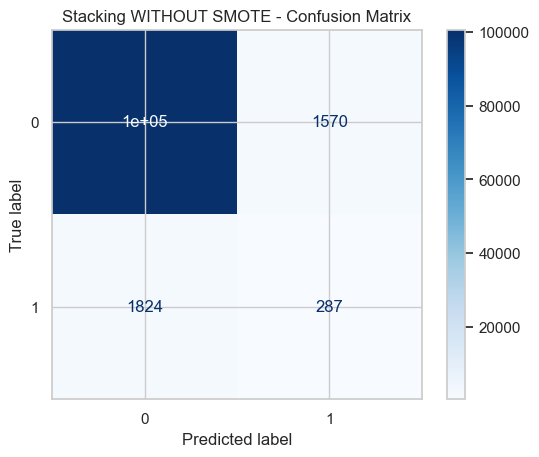

In [45]:
# Stacking: base learners XGB, RF, KNN --> final estimator RF
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, recall_score
import matplotlib.pyplot as plt
import numpy as np

# --- Common settings
random_state = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score),
    "recall_pos": make_scorer(recall_score, pos_label=1)
}

# --- Define base estimators
estimators = [
    ("xgb", XGBClassifier(n_estimators=150, use_label_encoder=False, verbosity=0,
                          eval_metric="aucpr", random_state=random_state)),
    ("rf_base", RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)),
    ("knn", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
]

final_estimator = RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1)

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=cv,
    n_jobs=-1,
    passthrough=False  # set True if you want original features concatenated to meta-inputs
)

# --- 1) WITHOUT SMOTE ---
print("=== Stacking WITHOUT SMOTE ===")
cv_res = cross_validate(stack_clf, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1, verbose=1)
print("CV results (mean):")
print({k: np.mean(v) for k, v in cv_res.items() if k.startswith("test_") or k.startswith("train_")})

# Fit on full train and evaluate on test
stack_clf.fit(X_train, y_train)
y_pred = stack_clf.predict(X_test)

print("\nTest set metrics (WITHOUT SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (pos):", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=stack_clf.classes_)
disp.plot(cmap="Blues")
plt.title("Stacking WITHOUT SMOTE - Confusion Matrix")
plt.show()





=== Stacking WITH SMOTE ===
Using SMOTE with k_neighbors=5 (positive_count=18610)
Class distribution before: [920238  18610] after: [920238 920238]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 189.6min finished


CV results with SMOTE (mean):
{'test_accuracy': 0.9823214211975597, 'train_accuracy': 0.9906755100311008, 'test_f1': 0.9821935853730617, 'train_f1': 0.9906264007908243, 'test_recall_pos': 0.9751423001440932, 'train_recall_pos': 0.9854287695139736}

Test set metrics (WITH SMOTE):
Accuracy: 0.9743228612763838
F1 (pos): 0.17385943279901356
              precision    recall  f1-score   support

           0     0.9823    0.9917    0.9870    102262
           1     0.2489    0.1336    0.1739      2111

    accuracy                         0.9743    104373
   macro avg     0.6156    0.5626    0.5804    104373
weighted avg     0.9675    0.9743    0.9705    104373

Confusion matrix:
 [[101411    851]
 [  1829    282]]


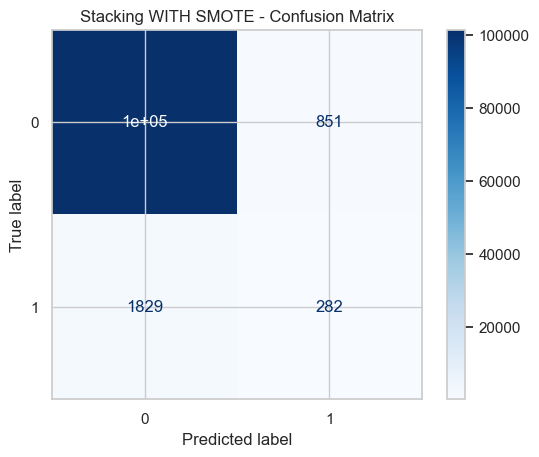

In [46]:
# --- 2) WITH SMOTE ---
print("\n\n=== Stacking WITH SMOTE ===")
from imblearn.over_sampling import SMOTE

positive_count = int((y_train == 1).sum())
# keep the same safe logic you used to pick k
k_neighbors = 5 if positive_count > 6 else max(1, positive_count - 1)
print(f"Using SMOTE with k_neighbors={k_neighbors} (positive_count={positive_count})")

smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Class distribution before:", np.bincount(y_train), "after:", np.bincount(y_train_res))

# Cross-validate stacking on resampled train
cv_res_smote = cross_validate(stack_clf, X_train_res, y_train_res, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1, verbose=1)
print("CV results with SMOTE (mean):")
print({k: np.mean(v) for k, v in cv_res_smote.items() if k.startswith("test_") or k.startswith("train_")})

# Fit on resampled train and evaluate on original test set
stack_clf.fit(X_train_res, y_train_res)
y_pred_sm = stack_clf.predict(X_test)

print("\nTest set metrics (WITH SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("F1 (pos):", f1_score(y_test, y_pred_sm))
print(classification_report(y_test, y_pred_sm, digits=4))
cm_sm = confusion_matrix(y_test, y_pred_sm)
print("Confusion matrix:\n", cm_sm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=stack_clf.classes_)
disp.plot(cmap="Blues")
plt.title("Stacking WITH SMOTE - Confusion Matrix")
plt.show()


Cross-validating EasyEnsemble on training set...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.4s finished


CV (mean) results:
{'test_accuracy': 0.8205620140165015, 'train_accuracy': 0.820438449185683, 'test_f1': 0.1116710763111019, 'train_f1': 0.1115464251879628}

Fitting EasyEnsemble on full training set...

Test set metrics (default 0.5 threshold):
Accuracy: 0.8170
Precision: 0.0600
Recall (sensitivity): 0.5486
F1 (pos): 0.1081

Classification report:
               precision    recall  f1-score   support

           0     0.9888    0.8225    0.8980    102262
           1     0.0600    0.5486    0.1081      2111

    accuracy                         0.8170    104373
   macro avg     0.5244    0.6855    0.5031    104373
weighted avg     0.9700    0.8170    0.8821    104373

Confusion matrix:
 [[84114 18148]
 [  953  1158]]


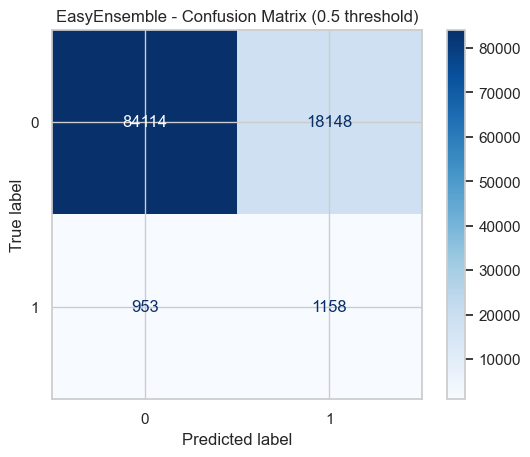


Chosen threshold (balancing spec & sens): 0.4833

Test set metrics (tuned threshold):
Accuracy: 0.7582
Precision: 0.0507
Recall (sensitivity): 0.6177
F1 (pos): 0.0937
Confusion matrix (tuned threshold):
 [[77836 24426]
 [  807  1304]]


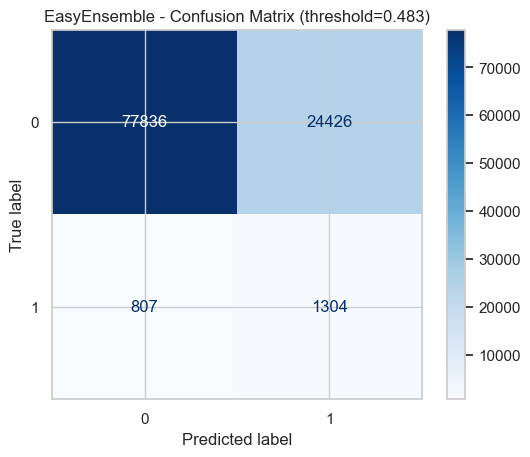

In [47]:
# EasyEnsemble classifier - ready to run
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve)
import matplotlib.pyplot as plt
import numpy as np

random_state = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

# --- define the classifier ---
# n_estimators = number of balanced sub-ensembles to build (increase for stability, costs more)
eec = EasyEnsembleClassifier(
    n_estimators=10,
    sampling_strategy='auto',  # balance minority/majority in each subset
    n_jobs=-1,
    random_state=random_state
)

scoring = ["accuracy", "f1"]

# --- cross-validate on original (imbalanced) training data ---
print("Cross-validating EasyEnsemble on training set...")
cv_res = cross_validate(eec, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1, verbose=1)
print("CV (mean) results:")
print({k: np.mean(v) for k, v in cv_res.items() if k.startswith("test_") or k.startswith("train_")})

# --- fit on full training set ---
print("\nFitting EasyEnsemble on full training set...")
eec.fit(X_train, y_train)

# --- predict on test set ---
y_pred = eec.predict(X_test)
y_prob = None
if hasattr(eec, "predict_proba"):
    # EasyEnsembleClassifier supports predict_proba (averages probabilities across ensemble)
    try:
        y_prob = eec.predict_proba(X_test)[:, 1]
    except Exception:
        y_prob = None

# --- basic metrics ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nTest set metrics (default 0.5 threshold):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall (sensitivity): {rec:.4f}")
print(f"F1 (pos): {f1:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=eec.classes_)
disp.plot(cmap="Blues")
plt.title("EasyEnsemble - Confusion Matrix (0.5 threshold)")
plt.show()

# -------------------------
# OPTIONAL: tune probability threshold to improve specificity (true negative rate)
# -------------------------
if y_prob is not None:
    fpr, tpr, thr = roc_curve(y_test, y_prob)
    specificity = 1 - fpr

    # Example: pick threshold that maximizes (specificity + tpr)/2  (you can choose other criteria)
    scores = 0.5 * (specificity + tpr)
    best_idx = np.argmax(scores)
    best_thr = thr[best_idx]
    print(f"\nChosen threshold (balancing spec & sens): {best_thr:.4f}")
    y_pred_thr = (y_prob >= best_thr).astype(int)

    acc_t = accuracy_score(y_test, y_pred_thr)
    prec_t = precision_score(y_test, y_pred_thr, zero_division=0)
    rec_t = recall_score(y_test, y_pred_thr, zero_division=0)
    f1_t = f1_score(y_test, y_pred_thr, zero_division=0)

    print("\nTest set metrics (tuned threshold):")
    print(f"Accuracy: {acc_t:.4f}")
    print(f"Precision: {prec_t:.4f}")
    print(f"Recall (sensitivity): {rec_t:.4f}")
    print(f"F1 (pos): {f1_t:.4f}")

    cm_thr = confusion_matrix(y_test, y_pred_thr)
    print("Confusion matrix (tuned threshold):\n", cm_thr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_thr, display_labels=eec.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"EasyEnsemble - Confusion Matrix (threshold={best_thr:.3f})")
    plt.show()
else:
    print("\npredict_proba not available from EasyEnsemble in this configuration; skip threshold tuning.")


In [48]:
# ----------------------------
# Run this AFTER your preprocessing step
# i.e., after you already executed:
# X_train = preprocessing_pipeline.fit_transform(X_train)
# X_test  = preprocessing_pipeline.transform(X_test)
# and you have y_train, y_test
# ----------------------------

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_recall_curve,
    average_precision_score, classification_report, confusion_matrix
)
import numpy as np
import joblib

random_state = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

# --- Build base estimators with imbalance-aware settings ---
# compute scale_pos_weight for xgboost from training labels
num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())
scale_pos_weight = max(1.0, num_neg / max(1, num_pos))

xgb_base = XGBClassifier(
    n_estimators=150,
    use_label_encoder=False,
    eval_metric="aucpr",
    verbosity=0,
    random_state=random_state,
    scale_pos_weight=scale_pos_weight
)

rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=random_state,
    n_jobs=-1,
    class_weight='balanced'      # make RF more sensitive to minority class
)

knn_base = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

estimators = [
    ("xgb", xgb_base),
    ("rf_base", rf_base),
    ("knn", knn_base)
]

final_estimator = RandomForestClassifier(
    n_estimators=300, random_state=random_state, n_jobs=-1, class_weight='balanced'
)

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

# Wrap stacking with SMOTE in an imblearn pipeline so resampling happens inside CV
smote = SMOTE(random_state=random_state, k_neighbors=5 if num_pos > 6 else max(1, num_pos-1))
stack_pipeline = ImbPipeline([
    ("smote", smote),
    ("stack", stack_clf)
])

# --- Cross-validate the pipeline (shows train/test metrics) ---
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "recall_pos": make_scorer(recall_score, pos_label=1)
}

print("Starting cross-validation (this may take a while)...")
cv_res = cross_validate(
    stack_pipeline, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

print("\nCV (mean) results:")
for k, v in cv_res.items():
    if k.startswith("train_") or k.startswith("test_"):
        print(f"{k}: {np.mean(v):.4f} (std {np.std(v):.4f})")

# --- Fit on all training data and evaluate on test set ---
print("\nFitting stack pipeline on full training data...")
stack_pipeline.fit(X_train, y_train)

# probabilities for positive class on test
if hasattr(stack_pipeline, "predict_proba"):
    y_proba = stack_pipeline.predict_proba(X_test)[:, 1]
else:
    # fallback: try inner estimator
    y_proba = stack_pipeline.named_steps["stack"].predict_proba(X_test)[:, 1]

# Default predictions (0.5 threshold)
y_pred_default = (y_proba > 0.5).astype(int)

print("\nDefault threshold (0.5) evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("F1 (pos):", f1_score(y_test, y_pred_default, zero_division=0))
print("Recall (pos):", recall_score(y_test, y_pred_default, zero_division=0))
print(classification_report(y_test, y_pred_default, digits=4))

# --- Precision-Recall curve + choose threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
print("PR-AUC (Average Precision):", ap)

# Find threshold that maximizes F1 (computed from precision & recall)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Best threshold (max F1) = {best_thresh:.4f}, F1 = {f1_scores[best_idx]:.4f}")

# If you prefer prioritize recall (e.g., get at least 0.6 recall), pick smallest threshold achieving it:
recall_target = 0.6
indices_meeting = np.where(recall >= recall_target)[0]
thresh_for_recall = None
if len(indices_meeting) > 0:
    idx = indices_meeting[-1]  # last index where recall >= target (gives highest precision among them)
    if idx < len(thresholds):
        thresh_for_recall = thresholds[idx]
    else:
        thresh_for_recall = 0.0

if thresh_for_recall is not None:
    print(f"Threshold achieving recall>= {recall_target}: {thresh_for_recall:.4f}")
else:
    print(f"No threshold achieves recall >= {recall_target} (max recall = {max(recall):.4f})")

# Apply the best threshold (max F1) to test set
y_pred_best = (y_proba > best_thresh).astype(int)
print("\nEvaluation at best (F1) threshold:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 (pos):", f1_score(y_test, y_pred_best, zero_division=0))
print("Recall (pos):", recall_score(y_test, y_pred_best, zero_division=0))
print(classification_report(y_test, y_pred_best, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))

# Optionally also evaluate threshold that prioritizes recall (if found)
if thresh_for_recall is not None:
    y_pred_recall = (y_proba > thresh_for_recall).astype(int)
    print(f"\nEvaluation at recall-target threshold ({recall_target}) = {thresh_for_recall:.4f}:")
    print("Accuracy:", accuracy_score(y_test, y_pred_recall))
    print("F1 (pos):", f1_score(y_test, y_pred_recall, zero_division=0))
    print("Recall (pos):", recall_score(y_test, y_pred_recall, zero_division=0))
    print(classification_report(y_test, y_pred_recall, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_recall))

# --- Save the pipeline + chosen threshold for inference ---
model_path = "stack_pipeline_smote.joblib"
joblib.dump({"pipeline": stack_pipeline, "best_threshold": float(best_thresh)}, model_path)
print(f"\nSaved trained pipeline and threshold to {model_path}")


Starting cross-validation (this may take a while)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 126.1min finished



CV (mean) results:
test_accuracy: 0.9742 (std 0.0005)
train_accuracy: 0.9960 (std 0.0005)
test_f1: 0.1678 (std 0.0042)
train_f1: 0.9034 (std 0.0100)
test_recall_pos: 0.1313 (std 0.0039)
train_recall_pos: 0.9512 (std 0.0021)

Fitting stack pipeline on full training data...

Default threshold (0.5) evaluation:
Accuracy: 0.974073754706677
F1 (pos): 0.17650639074863056
Recall (pos): 0.13737565135007104
              precision    recall  f1-score   support

           0     0.9824    0.9913    0.9868    102262
           1     0.2468    0.1374    0.1765      2111

    accuracy                         0.9741    104373
   macro avg     0.6146    0.5644    0.5817    104373
weighted avg     0.9675    0.9741    0.9704    104373

PR-AUC (Average Precision): 0.10565716141667027
Best threshold (max F1) = 0.2600, F1 = 0.1964
Threshold achieving recall>= 0.6: 0.0000

Evaluation at best (F1) threshold:
Accuracy: 0.9695706744081324
F1 (pos): 0.1955420466058764
Recall (pos): 0.18285172903837044
       

PCA AND CLASS Weights

In [49]:
# %% PCA + Class Weights + Stacking Ensemble

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer
)
import matplotlib.pyplot as plt
import numpy as np

# --- Common settings ---
random_state = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score),
    "recall_pos": make_scorer(recall_score, pos_label=1)
}

# --- Compute scale_pos_weight for XGBoost ---
num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())
scale_pos_weight = max(1.0, num_neg / max(1, num_pos))

# --- Base estimators (with class weights) ---
xgb_base = XGBClassifier(
    n_estimators=150,
    use_label_encoder=False,
    eval_metric="aucpr",
    verbosity=0,
    random_state=random_state,
    scale_pos_weight=scale_pos_weight
)

rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=random_state,
    n_jobs=-1,
    class_weight='balanced'
)

knn_base = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

estimators = [
    ("xgb", xgb_base),
    ("rf_base", rf_base),
    ("knn", knn_base)
]

final_estimator = RandomForestClassifier(
    n_estimators=300,
    random_state=random_state,
    n_jobs=-1,
    class_weight='balanced'
)

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

# --- PCA for dimensionality reduction ---
pca = PCA(n_components=0.95, random_state=random_state)  # keeps 95% of variance

# --- Full pipeline: PCA → Stacking ---
stack_pca_pipeline = Pipeline([
    ("pca", pca),
    ("stack", stack_clf)
])

# --- Cross-validation ---
print("=== PCA + Class Weights + Stacking ===")
cv_res = cross_validate(
    stack_pca_pipeline, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=-1, verbose=1
)

print("\nCV (mean ± std) results:")
for k, v in cv_res.items():
    if k.startswith("train_") or k.startswith("test_"):
        print(f"{k}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# --- Fit on full training data ---
stack_pca_pipeline.fit(X_train, y_train)

# --- Evaluate on test set ---
y_pred = stack_pca_pipeline.predict(X_test)

print("\nTest set metrics (PCA + Class Weights + Stacking):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (pos):", f1_score(y_test, y_pred))
print("Recall (pos):", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=stack_clf.classes_)
disp.plot(cmap="Blues")
plt.title("PCA + Class Weights + Stacking - Confusion Matrix")
plt.show()

# --- Explained variance info ---
explained = stack_pca_pipeline.named_steps["pca"].explained_variance_ratio_
print(f"\nPCA reduced features from {X_train.shape[1]} → {len(explained)} components.")
print(f"Total variance retained: {sum(explained)*100:.2f}%")


=== PCA + Class Weights + Stacking ===


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 69.4min finished



CV (mean ± std) results:
test_accuracy: 0.9652 ± 0.0001
train_accuracy: 0.9689 ± 0.0005
test_f1: 0.0580 ± 0.0013
train_f1: 0.0704 ± 0.0123
test_recall_pos: 0.0540 ± 0.0013
train_recall_pos: 0.0594 ± 0.0106


KeyboardInterrupt: 